<a href="https://colab.research.google.com/github/chrispchen/ChenHypoxia/blob/main/scRNA-seq%20analysis/cNMF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Consensus Non-negative Matrix Factorization (cNMF)

The goal here is to determine activity and identity gene expression programs during normal and paused development using cNMF

cNMF citation:

Dylan KotliarAdrian VeresM Aurel NagyShervin TabriziEran HodisDouglas A MeltonPardis C Sabeti (2019) Identifying gene expression programs of cell-type identity and cellular activity with single-cell RNA-Seq eLife 8:e43803.
https://doi.org/10.7554/eLife.43803

##Set up enviornment

In [ ]:
!pip install cnmf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 8.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
import cnmf
from cnmf import cNMF
import scanpy as sc

%matplotlib inline

import os
import pandas as pd
import numpy as np
from scipy.io import mmread
import scipy.sparse as sp
import matplotlib.pyplot as plt
from IPython.display import Image


np.random.seed(14)

In [ ]:
# Clone cNMF from Github
if not os.path.exists('cNMF'):
    !git clone https://github.com/dylkot/cNMF.git

Cloning into 'cNMF'...
remote: Enumerating objects: 924, done.
remote: Counting objects: 100% (499/499), done.
remote: Compressing objects: 100% (210/210), done.
remote: Total 924 (delta 285), reused 318 (delta 273), pack-reused 425 (from 1)
Receiving objects: 100% (924/924), 17.97 MiB | 34.39 MiB/s, done.
Resolving deltas: 100% (466/466), done.


# Load data

In [ ]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive/')
data_path = '/your/path/'  #change dir to your project folder

Mounted at /content/drive/


## Dataset preparation
From [dylan's github](https://github.com/dylkot/cNMF) there are a few considerations

- the cells by genes matrix cannot possess any zeros, these will cause errors
- the expression matrix should be raw, normalization and differentially expressed genes are calculated within cNMF's code


In [ ]:
# make expression matrix raw from .layers
#adata.X = adata.layers['raw_nolog']
#adata.X  # remove any potential zeros by filtering
#sc.pp.filter_cells(adata, min_genes=200) # filter cells with fewer than 200 genes
#sc.pp.filter_cells(adata, min_counts=200)  # This is a weaker threshold than above. It is just to population the n_counts column in adata
#sc.pp.filter_genes(adata, min_cells=3) # filter genes detected in fewer than 3 cells

In [ ]:
adata = sc.read('/your/path/yourScdataset.h5ad')

# k selection
I already ran portions of cNMF (similar to below) on a cluster surveying many K values, here are the results

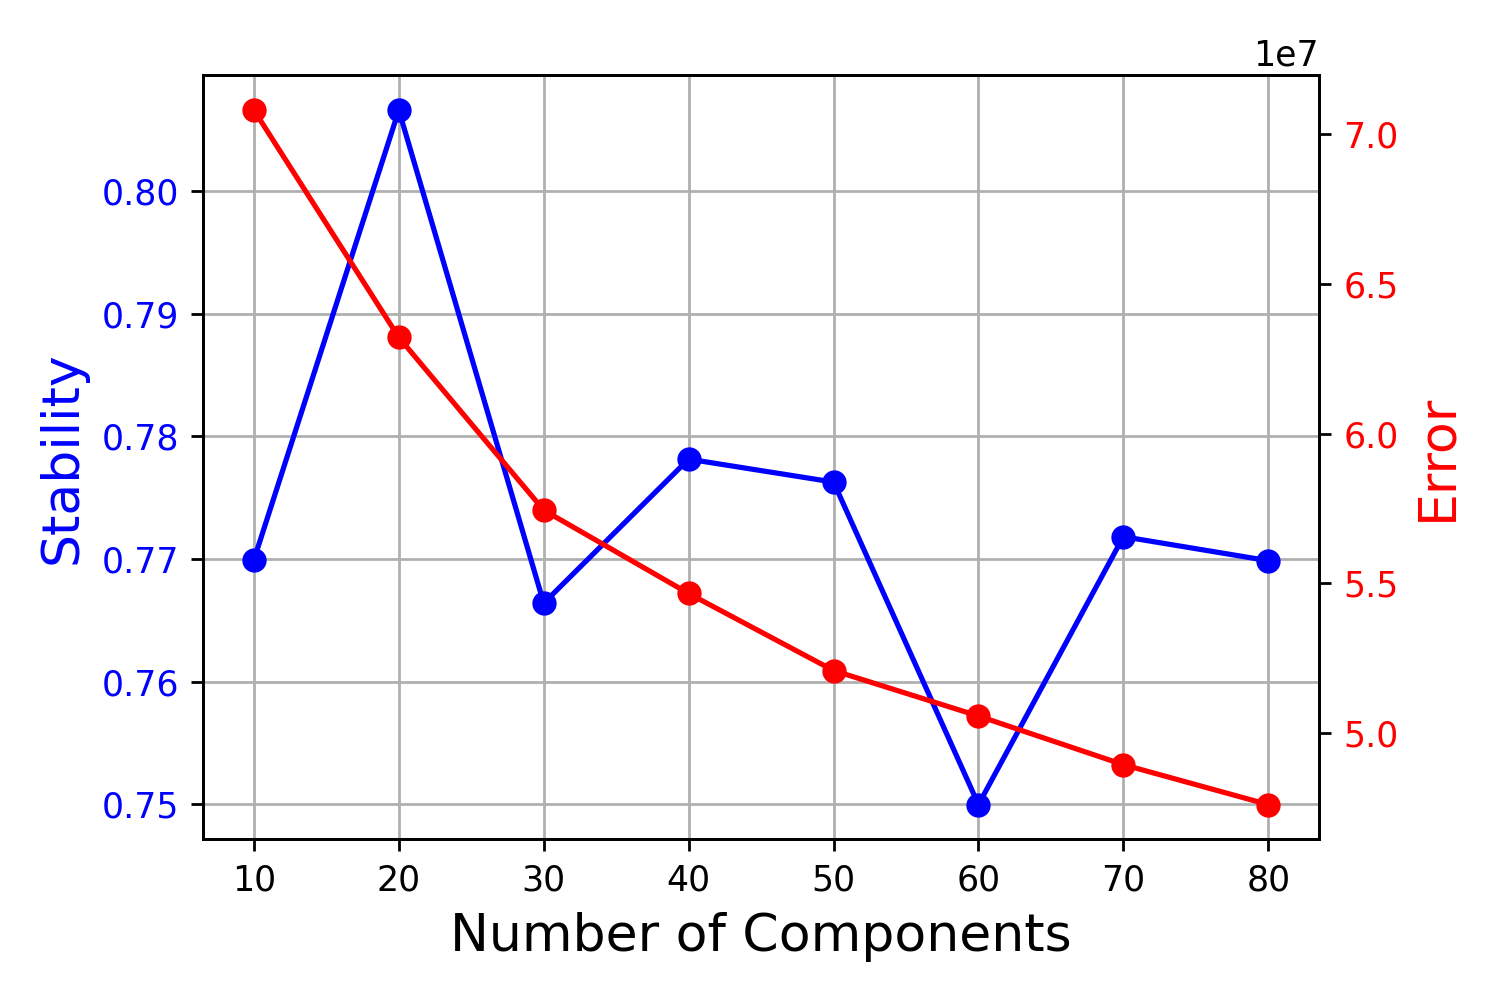

In [ ]:
## Here is the image of the k selection plot

Image(filename = '/your/path/k_selection_large.png', width=800, height=600)

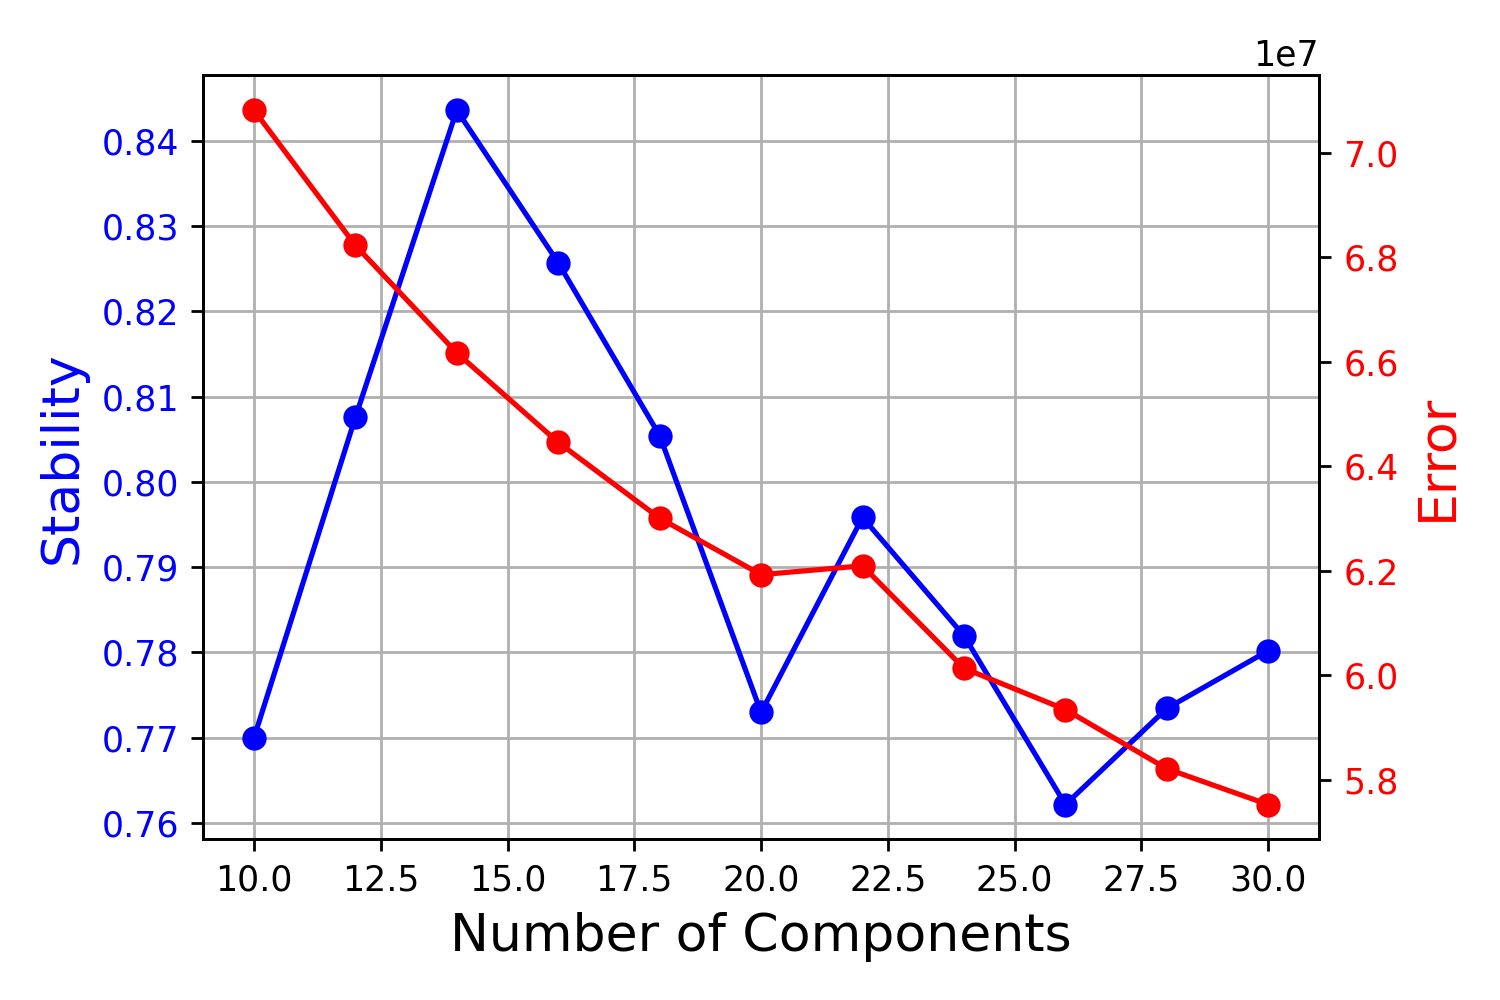

In [ ]:
## Here is the image of the k selection plot

Image(filename = '/your/path/k_selection_small.png', width=800, height=600)

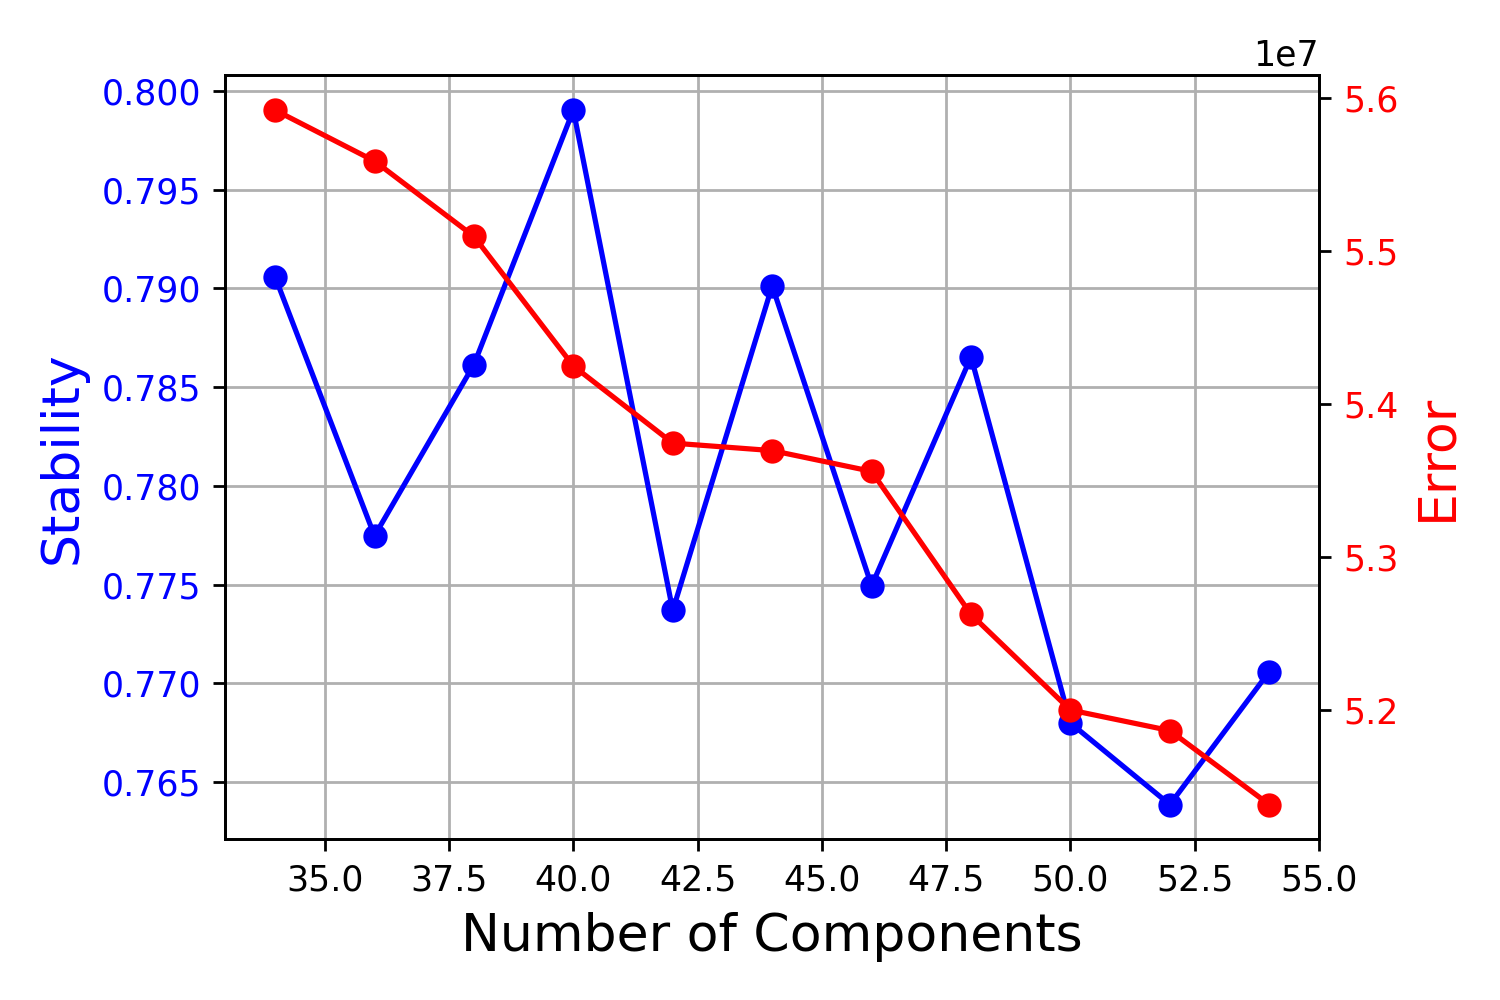

In [ ]:
## Here is the image of the k selection plot

Image(filename = '/your/path/Hypox.k_selection_40.png', width=800, height=600)

## CNMF time

In [ ]:
# cNMF settings (modify as needed)
cNMF_n_iter = 50
cNMF_n_var_genes = 2000
cNMF_output_dir = '/your/path/cNMF'
cNMF_run_name = 'hypox_trial3'
cNMF_k_range = '40'
cNMF_rand_seed = 14
cNMF_input_data = '/your/path/yourScdataset.h5ad'

In [ ]:
# Run cNMF directly in shell (this code block should not need any modification)
if not os.path.exists(cNMF_output_dir):
    os.mkdir(cNMF_output_dir)

# Set up the shell commands
prepare_cmd = 'python -W ignore /content/cNMF/src/cnmf/cnmf.py prepare --output-dir %s --name %s -c %s -k %s --n-iter %d --total-workers 1 --seed %d --numgenes %d --beta-loss frobenius' % (cNMF_output_dir, cNMF_run_name, cNMF_input_data, cNMF_k_range, cNMF_n_iter, cNMF_rand_seed, cNMF_n_var_genes)
factorize_cmd = 'python -W ignore /content/cNMF/src/cnmf/cnmf.py factorize --output-dir %s --name %s --worker-index 0' % (cNMF_output_dir, cNMF_run_name)
combine_cmd = 'python -W ignore /content/cNMF/src/cnmf/cnmf.py combine --output-dir %s --name %s' % (cNMF_output_dir, cNMF_run_name)
kselect_plot_cmd = 'python -W ignore /content/cNMF/src/cnmf/cnmf.py k_selection_plot --output-dir %s --name %s' % (cNMF_output_dir, cNMF_run_name)

# Execute shell commands
print('Prepare:\n %s' % (prepare_cmd))
! {prepare_cmd}
print('Factorize:\n %s' % (factorize_cmd))
!{factorize_cmd}
print('Combine:\n %s' % (combine_cmd))
!{combine_cmd}
print('K-selection Plot:\n %s' % (kselect_plot_cmd))
!{kselect_plot_cmd}

Prepare:
 python -W ignore /content/cNMF/src/cnmf/cnmf.py prepare --output-dir /content/drive/MyDrive/Chris/All/cNMF --name hypox_trial3 -c /content/drive/MyDrive/Chris/All/h5ad/CPC_All_CellTypist_gentle_minus_onlyWT_forcNMF.h5ad -k 40 --n-iter 50 --total-workers 1 --seed 14 --numgenes 2000 --beta-loss frobenius
Factorize:
 python -W ignore /content/cNMF/src/cnmf/cnmf.py factorize --output-dir /content/drive/MyDrive/Chris/All/cNMF --name hypox_trial3 --worker-index 0
[Worker 0]. Starting task 0.
[Worker 0]. Starting task 1.
[Worker 0]. Starting task 2.
[Worker 0]. Starting task 3.
[Worker 0]. Starting task 4.
[Worker 0]. Starting task 5.
[Worker 0]. Starting task 6.
[Worker 0]. Starting task 7.
[Worker 0]. Starting task 8.
[Worker 0]. Starting task 9.
[Worker 0]. Starting task 10.
[Worker 0]. Starting task 11.
[Worker 0]. Starting task 12.
[Worker 0]. Starting task 13.
[Worker 0]. Starting task 14.
[Worker 0]. Starting task 15.
[Worker 0]. Starting task 16.
[Worker 0]. Starting task 17

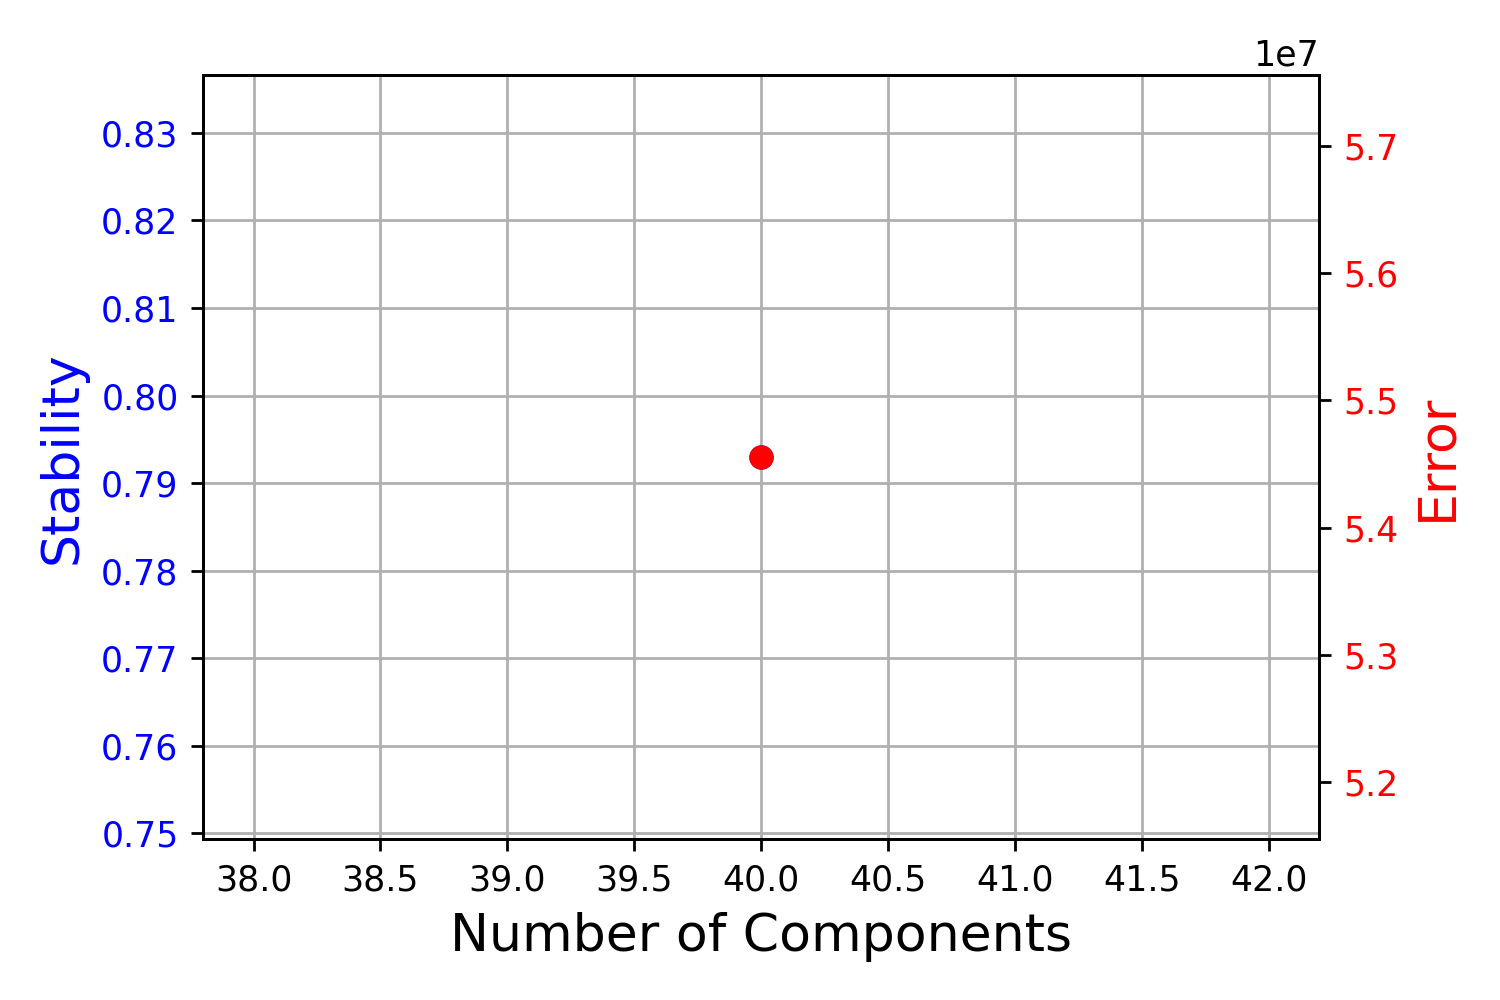

In [ ]:
# Inspect the 'K selection' plot
kselect_plot_path = '/%s/%s/%s.k_selection.png' % (cNMF_output_dir, cNMF_run_name, cNMF_run_name)
Image(filename = kselect_plot_path, width=800, height=800)

In [ ]:
# Choose consensus parameters (modify as needed)
cNMF_k = 40
cNMF_local_density_thresh = 2


In [ ]:

# Set up and run the consensus shell command
consensus_cmd = 'python -W ignore /content/cNMF/src/cnmf/cnmf.py consensus --output-dir %s --name %s --local-density-threshold %.2f --components %d --show-clustering' % (cNMF_output_dir, cNMF_run_name, cNMF_local_density_thresh, cNMF_k)
print('Consensus:\n %s' % (consensus_cmd))
! {consensus_cmd}


Consensus:
 python -W ignore /content/cNMF/src/cnmf/cnmf.py consensus --output-dir /content/drive/MyDrive/Chris/All/cNMF --name hypox_trial3 --local-density-threshold 2.00 --components 40 --show-clustering


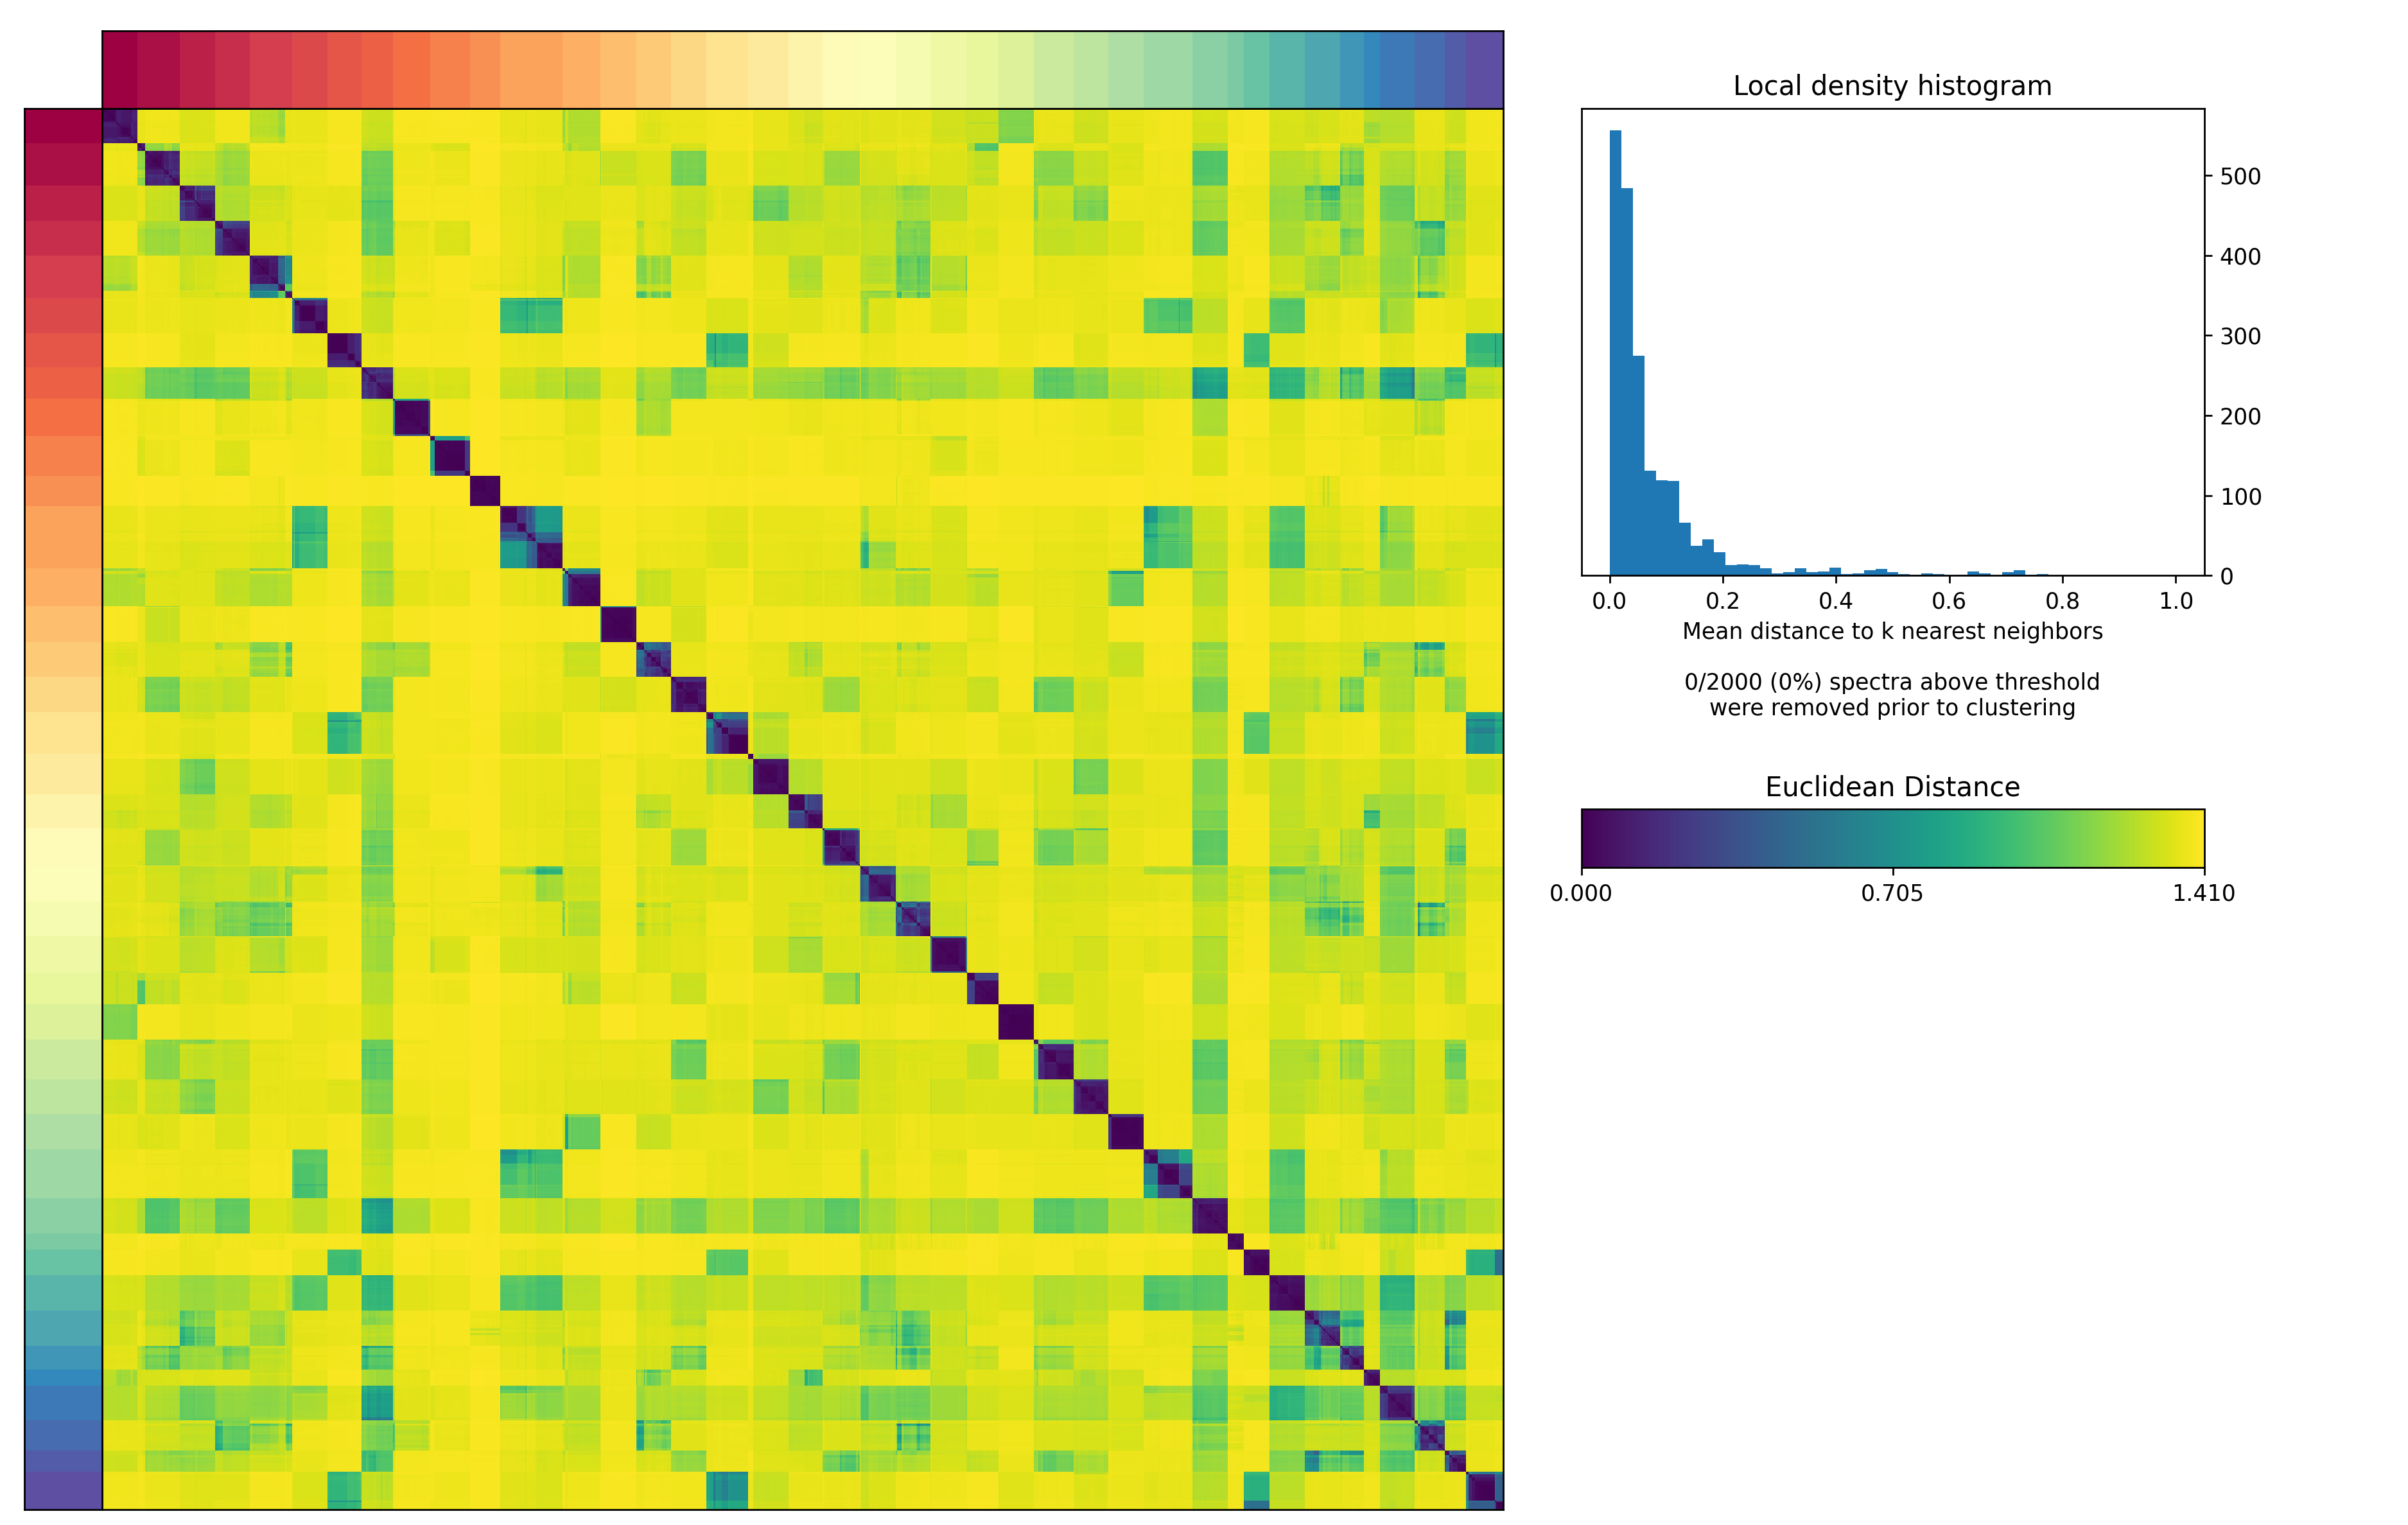

In [ ]:

# Inspect the consensus plot
consensus_plot_path = '%s/%s/%s.clustering.k_%d.dt_%s.png' % (cNMF_output_dir, cNMF_run_name, cNMF_run_name,cNMF_k,('%.1f' % cNMF_local_density_thresh).replace('.', '_'))
Image(filename = consensus_plot_path, width=800, height=600)


In [ ]:
# Load cNMF usage matrix into ScanPy
usage_path = '/%s/%s/%s.usages.k_%d.dt_%s.consensus.txt' % (cNMF_output_dir, cNMF_run_name, cNMF_run_name,cNMF_k,('%.1f' % cNMF_local_density_thresh).replace('.', '_'))
usage_matrix = pd.read_csv(usage_path, sep='\t', index_col=0)
usage_matrix.columns = ['GEP_%s' % i for i in usage_matrix.columns]
usage_matrix = usage_matrix.div(usage_matrix.sum(axis=1), axis=0)
for x in usage_matrix.columns:
  adata.obs[x] = usage_matrix[x]

usage_matrix.to_csv('/your/path/UsageMatrix_k40.csv') # SAVE THIS FILE FOR FUTURE

# Verify that new columns were added
adata.obs[usage_matrix.columns]

,GEP_1,GEP_2,GEP_3,GEP_4,GEP_5,GEP_6,GEP_7,GEP_8,GEP_9,GEP_10,...,GEP_31,GEP_32,GEP_33,GEP_34,GEP_35,GEP_36,GEP_37,GEP_38,GEP_39,GEP_40
13_01_72__s1-16,0.167147,0.015953,0.391932,0.000000,0.106827,0.000000,0.000000,0.000000,0.170229,0.000000,...,0.000000,0.009234,0.000000,0.000000,9.983394e-07,0.000000,0.000292,0.000000,0.015660,0.0
13_02_35__s1-16,0.000000,0.000000,0.152455,0.000000,0.161138,0.000000,0.000000,0.000000,0.384646,0.000000,...,0.000000,0.000000,0.000000,0.036216,5.915745e-04,0.000000,0.000914,0.000000,0.001781,0.0
13_02_84__s1-16,0.397519,0.000000,0.000000,0.191054,0.282073,0.037839,0.042126,0.000000,0.003443,0.000000,...,0.000000,0.000000,0.000000,0.001455,1.058933e-03,0.002311,0.001089,0.000000,0.003193,0.0
13_02_88__s1-16,0.128799,0.223871,0.036041,0.000000,0.376770,0.000000,0.108270,0.016613,0.000000,0.000000,...,0.001346,0.005562,0.000000,0.000000,6.163402e-03,0.006634,0.002884,0.000040,0.000317,0.0
13_02_91__s1-16,0.563303,0.055304,0.000000,0.051138,0.306033,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000576,0.006060,0.002630,0.000000,0.000000e+00,0.000650,0.002111,0.001800,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24_91_70__s8-47,0.116251,0.000000,0.000000,0.386994,0.042859,0.000000,0.000000,0.012998,0.050887,0.000000,...,0.000000,0.004253,0.001248,0.000000,0.000000e+00,0.000671,0.002982,0.000000,0.008023,0.0
24_93_06__s8-47,0.046452,0.000614,0.000000,0.160927,0.057905,0.129156,0.000000,0.118477,0.000000,0.020129,...,0.000000,0.003180,0.000557,0.000000,0.000000e+00,0.000000,0.000000,0.002476,0.000748,0.0
24_93_82__s8-47,0.000000,0.000000,0.000000,0.000000,0.000000,0.094449,0.085366,0.238601,0.011328,0.000000,...,0.000276,0.000000,0.012241,0.000557,0.000000e+00,0.000000,0.000000,0.007284,0.000000,0.0
24_95_23__s8-47,0.410916,0.074158,0.016078,0.033826,0.062596,0.153070,0.000000,0.046158,0.000000,0.000000,...,0.002923,0.001814,0.000000,0.000000,6.375191e-03,0.001517,0.000000,0.000000,0.000000,0.0


In [ ]:
# Obtain the top z-scored genes for each GEP
pd.options.display.max_columns = None
n_top_genes = 2000

gene_scores_path = '/%s/%s/%s.gene_spectra_score.k_%d.dt_%s.txt' % (cNMF_output_dir, cNMF_run_name, cNMF_run_name,cNMF_k,('%.1f' % cNMF_local_density_thresh).replace('.', '_'))
gene_scores = pd.read_csv(gene_scores_path, sep='\t', index_col=0).T

top_genes = []
for gep in gene_scores.columns:
    top_genes.append(list(gene_scores.sort_values(by=gep, ascending=False).index[:n_top_genes]))
top_genes = pd.DataFrame(top_genes, index=usage_matrix.columns).T


top_genes.to_csv('/your/path/top_genes_k40.csv')

top_genes

In [ ]:
top_genes

,GEP_1,GEP_2,GEP_3,GEP_4,GEP_5,GEP_6,GEP_7,GEP_8,GEP_9,GEP_10,GEP_11,GEP_12,GEP_13,GEP_14,GEP_15,GEP_16,GEP_17,GEP_18,GEP_19,GEP_20,GEP_21,GEP_22,GEP_23,GEP_24,GEP_25,GEP_26,GEP_27,GEP_28,GEP_29,GEP_30,GEP_31,GEP_32,GEP_33,GEP_34,GEP_35,GEP_36,GEP_37,GEP_38,GEP_39,GEP_40
0,cxcr4b,foxi1,tbxta,sfrp1a,ppp1r15a,lmo4a,tiam1b,adgrl2a,efnb2a,hoxa9a,fn1b,znf385b,lhx2b,wnt7ab,itga3b,wnt1,six4b,slc39a5,cyp26c1,fbln2,tbx6,pou5f3,rbpms2a,sox17,apobb.1,fzd8b,twist1a,nkx2.4b,bmp16,rbl2,tmtopsb,ppp1r9alb,emilin3a,ttn.2,bicc2,si:dkey-269i1.4,dlb,si:cabz01007794.1,krt5,dnd1
1,marcksl1b,tfap2a,eve1,otx1,tent5ba,rnf220a,rgs3b,FP565432.1,fscn1a,hoxc3a,msgn1,igf2bp2a,zic1,irx3b,cldni,en2a,ptgs2a,slc7a8a,vgll3,noto,rdh10a,add3b,hand2,gpm6ab,pcxb,frzb,colec12,nkx2.1,kif19,foxo3b,camk2d1,si:ch211-125o16.4,col8a1a,efemp2a,crocc2,calr3b,zgc:158291,atp10b,krt4,tdrd7a
2,ddx5,klf2b,dld,cyp26a1,mknk2b,hyal2b,si:ch211-151g22.1,znf1004,aplnrb,hoxc8a,fzd10,spag9a,rx3,bicd1a,sema3b,pax2a,eya1,lrrfip1b,epha7,twist2,LOC101886882,sall4,si:dkey-73n10.1,sox32,slc47a1,gsc,lsp1,shhb,hs3st2,LOC100537178,rapgef3,slc2a12,pmp22b,ttn.1,pkd1l1,si:dkey-239j18.2,elavl3,SAMD12,krt99,si:ch211-241j12.3
3,ctcf,dlx3b,hes6,otx2a,mcl1b,foxb1a,fgfr1b,jarid2b,efnb2b,hoxd3a,tbx16l,erfl3,rims2b,cgnl1,zgc:86896,her5,pla2g4aa,abtb2a,cyp26b1,epha4a,LOC110438394,acin1b,CR387932.1,pltp,zgc:136410,klf17,fsta,nkx2.4a,glra1,mdm2,card11,hsd17b12a,CR381618.1,mef2d,she,ctslb,onecutl,LOC100330916,krt8,nanos3
4,polr3gla,tfap2c,itgb5,plxdc2,pim2,chrd,slc38a3b,zgc:110796,trib3,nradd,ephb3,ptprub,nr2f5,wnt11r,lama5,wnt8b,znf385a,slc43a3b,olig3,foxa2,XLOC_042229,lrwd1,pdgfra,iqca1,zgc:112265,si:ch211-163l21.8,mark4a,dbx1a,vipr2,bbc3,fam19a5b,fa2h,sema5bb,myl10,syne1b,he1.1,tlx3b,slc35a3b,krt18a.1,si:ch211-241j12.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,ing2,si:ch211-155e24.3,selenot1b,RF01268,iqcc,pop7,yars2,si:ch73-103b11.2,tent5bb,nup93,CABZ01085878.1,mrps22,sugp1,ybx1,siae,ophn1,skiv2l,tgfbr3,trim24,psmd4b,ywhabb,RF00431,XLOC_034584,XLOC_023375,slco1d1,sh3gl2b,LOC100330186,rfc2,si:ch211-209f23.6,ctnnbl1,CABZ01052570.1,cavin1a,pcdh2g10,sema7a,slc35b2,LOC101884161,apoc1,LOC110438534,bcap29,arpp19b
1996,upf3b,CU695011.1,zgc:77486,zgc:172121,FO704721.2,BX649295.1,agla,metap1d,LOC101886161,phkb,tnksa,mier1b,kif3a,CR855865.1,dgke,CABZ01058046.1,tsga10,cubn,cse1l,npr1a,LOC103912048,tefb,c8a,dixdc1a,BX890602.1,sar1b,taok1b,tmem184c,zbtb41,shprh,ccdc167,ndr1,CU659670.1,CT027582.1,BX901883.2,XLOC_004994,ckmt2a,abhd17b,pdcd6ip,flii
1997,miip,CABZ01102109.1,smu1a,znf644a,unm_hu7910,msl1b,si:ch73-335l21.1,si:ch73-1a9.4,cdh30,fbxo45,itga11a,CABZ01054394.1,zgc:85936,BX001014.1,cacna1i,inpp4aa,ttc6,alas1,diaph3,cdc42ep4b,SFMBT1,XLOC_020730,mtmr3,LOC101882848,si:ch211-186e20.2,pmm2,rrbp1b,pkn1a,rp9,si:dkey-49c17.4,fuca2,fbxw11b,kctd12.1,CABZ01031870.1,dusp1,BX547939.1,man2b1,CABZ01079267.1,si:ch73-223f5.1,dcaf5
1998,glrx,strada,gtf2a1,dctpp1,ptger4a,map3k3,MARF1,oclna,scarb2c,bokb,col5a1,zgc:85843,tmem165,BX323884.1,wrn,si:ch211-253h3.1,osbpl3a,FP236812.1,mir301b,LOC795545,LOC100149991,pip5k1ab,myo1b,si:dkeyp-46h3.2,cst14b.2,lrrc8db,pms2,ppp2r5ca,c2cd3,znf1130,setd7,LOC110439407,zgc:153240,cope,cep104,taar20b,xkrx,ethe1,XLOC_039965,zgc:136254


In [ ]:
# the above steps can take a while to run, I'd recommend writing the .h5ad here as a good stopping point

adata.write('/your/path/yourScdataset_forcNMF_k40.h5ad')

# Gene expression program (GEP) classification and characterization

In [2]:
!pip install scanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 137.5 MB/s eta 0:00:00


In [3]:
import glob
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, fisher_exact, pearsonr
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import scanpy as sc

In [5]:
adata = sc.read('/your/path/yourScdataset_forcNMF_k40.h5ad')

In [8]:
clusters = adata.obs['majority_voting'].unique().tolist()
all_GEPs = adata.obs.columns.tolist()
all_GEPs = all_GEPs[42:83]

In [9]:
clusters

['Dorsal margin',
 'Non dorsal margin involuted',
 'Ectoderm dorsal',
 'Ectoderm ventral',
 'YSL',
 'Prechordal plate',
 'Endoderm',
 'Forerunner cells',
 'EVL',
 'Neural plate posterior',
 'Epidermis 8hpf',
 'Notochord',
 'Tailbud PSM',
 'Tailbud spinal cord 8hpf',
 'Mesoderm adaxial cells',
 'Germline',
 'Neural plate anterior',
 'Neural midhindbrain',
 'Tailbud spinal cord 2',
 'Mesoderm lateral plate',
 'Tailbud spinal cord 1',
 'Epidermis 10hpf',
 'Neural diencephalon',
 'Neural anterior']

In [10]:
usage_matrix = pd.read_csv('/your/path/UsageMatrix_k40.csv', index_col=0)

In [11]:
usage_matrix

,GEP_1,GEP_2,GEP_3,GEP_4,GEP_5,GEP_6,GEP_7,GEP_8,GEP_9,GEP_10,...,GEP_31,GEP_32,GEP_33,GEP_34,GEP_35,GEP_36,GEP_37,GEP_38,GEP_39,GEP_40
13_01_72__s1-16,0.167147,0.015953,0.391932,0.000000,0.106827,0.000000,0.000000,0.000000,0.170229,0.000000,...,0.000000,0.009234,0.000000,0.000000,9.983394e-07,0.000000,0.000292,0.000000,0.015660,0.0
13_02_35__s1-16,0.000000,0.000000,0.152455,0.000000,0.161138,0.000000,0.000000,0.000000,0.384646,0.000000,...,0.000000,0.000000,0.000000,0.036216,5.915745e-04,0.000000,0.000914,0.000000,0.001781,0.0
13_02_84__s1-16,0.397519,0.000000,0.000000,0.191054,0.282073,0.037839,0.042126,0.000000,0.003443,0.000000,...,0.000000,0.000000,0.000000,0.001455,1.058933e-03,0.002311,0.001089,0.000000,0.003193,0.0
13_02_88__s1-16,0.128799,0.223871,0.036041,0.000000,0.376770,0.000000,0.108270,0.016613,0.000000,0.000000,...,0.001346,0.005562,0.000000,0.000000,6.163402e-03,0.006634,0.002884,0.000040,0.000317,0.0
13_02_91__s1-16,0.563303,0.055304,0.000000,0.051138,0.306033,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000576,0.006060,0.002630,0.000000,0.000000e+00,0.000650,0.002111,0.001800,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24_91_70__s8-47,0.116251,0.000000,0.000000,0.386994,0.042859,0.000000,0.000000,0.012998,0.050887,0.000000,...,0.000000,0.004253,0.001248,0.000000,0.000000e+00,0.000671,0.002982,0.000000,0.008023,0.0
24_93_06__s8-47,0.046452,0.000614,0.000000,0.160927,0.057905,0.129156,0.000000,0.118477,0.000000,0.020129,...,0.000000,0.003180,0.000557,0.000000,0.000000e+00,0.000000,0.000000,0.002476,0.000748,0.0
24_93_82__s8-47,0.000000,0.000000,0.000000,0.000000,0.000000,0.094449,0.085366,0.238601,0.011328,0.000000,...,0.000276,0.000000,0.012241,0.000557,0.000000e+00,0.000000,0.000000,0.007284,0.000000,0.0
24_95_23__s8-47,0.410916,0.074158,0.016078,0.033826,0.062596,0.153070,0.000000,0.046158,0.000000,0.000000,...,0.002923,0.001814,0.000000,0.000000,6.375191e-03,0.001517,0.000000,0.000000,0.000000,0.0


## Identity GEPs

'Identity GEPs' should be akin to cell identity programs, ideally they represent core expression programs that are invariante across conditions and are similar to cell marker genes

In [13]:

mono_identity_geps_dict2 = dict(percent_group_usage.idxmax())
mono_identity_geps_df2 = pd.DataFrame(percent_group_usage.idxmax())
mono_identity_geps_dict2

{'GEP_1': 'Ectoderm ventral',
 'GEP_2': 'Epidermis 8hpf',
 'GEP_3': 'Tailbud spinal cord 8hpf',
 'GEP_4': 'Neural plate anterior',
 'GEP_5': 'YSL',
 'GEP_6': 'Neural plate posterior',
 'GEP_7': 'YSL',
 'GEP_8': 'YSL',
 'GEP_9': 'Non dorsal margin involuted',
 'GEP_10': 'Tailbud spinal cord 2',
 'GEP_11': 'Tailbud PSM',
 'GEP_12': 'YSL',
 'GEP_13': 'Neural anterior',
 'GEP_14': 'Tailbud spinal cord 1',
 'GEP_15': 'Epidermis 10hpf',
 'GEP_16': 'Neural midhindbrain',
 'GEP_17': 'Epidermis 10hpf',
 'GEP_18': 'YSL',
 'GEP_19': 'Neural midhindbrain',
 'GEP_20': 'Notochord',
 'GEP_21': 'Tailbud PSM',
 'GEP_22': 'YSL',
 'GEP_23': 'Mesoderm lateral plate',
 'GEP_24': 'Endoderm',
 'GEP_25': 'YSL',
 'GEP_26': 'Prechordal plate',
 'GEP_27': 'Mesoderm lateral plate',
 'GEP_28': 'Neural diencephalon',
 'GEP_29': 'YSL',
 'GEP_30': 'Ectoderm ventral',
 'GEP_31': 'EVL',
 'GEP_32': 'EVL',
 'GEP_33': 'Notochord',
 'GEP_34': 'Mesoderm adaxial cells',
 'GEP_35': 'Forerunner cells',
 'GEP_36': 'Prechordal p

In [14]:
transposed = percent_group_usage.T
mono_identity_geps_dict = dict(transposed.idxmax())
mono_identity_geps_df = pd.DataFrame(transposed.idxmax())
mono_identity_geps_dict

{'Dorsal margin': 'GEP_1',
 'Non dorsal margin involuted': 'GEP_9',
 'Ectoderm dorsal': 'GEP_1',
 'Ectoderm ventral': 'GEP_1',
 'YSL': 'GEP_5',
 'Prechordal plate': 'GEP_20',
 'Endoderm': 'GEP_24',
 'Forerunner cells': 'GEP_35',
 'EVL': 'GEP_31',
 'Neural plate posterior': 'GEP_6',
 'Epidermis 8hpf': 'GEP_2',
 'Notochord': 'GEP_20',
 'Tailbud PSM': 'GEP_11',
 'Tailbud spinal cord 8hpf': 'GEP_3',
 'Mesoderm adaxial cells': 'GEP_11',
 'Germline': 'GEP_40',
 'Neural plate anterior': 'GEP_4',
 'Neural midhindbrain': 'GEP_16',
 'Tailbud spinal cord 2': 'GEP_10',
 'Mesoderm lateral plate': 'GEP_27',
 'Tailbud spinal cord 1': 'GEP_14',
 'Epidermis 10hpf': 'GEP_15',
 'Neural diencephalon': 'GEP_28',
 'Neural anterior': 'GEP_13'}

In [15]:
row_order = mono_identity_geps_df[0].to_list()
row_order

['GEP_1',
 'GEP_9',
 'GEP_1',
 'GEP_1',
 'GEP_5',
 'GEP_20',
 'GEP_24',
 'GEP_35',
 'GEP_31',
 'GEP_6',
 'GEP_2',
 'GEP_20',
 'GEP_11',
 'GEP_3',
 'GEP_11',
 'GEP_40',
 'GEP_4',
 'GEP_16',
 'GEP_10',
 'GEP_27',
 'GEP_14',
 'GEP_15',
 'GEP_28',
 'GEP_13']

In [16]:
row_order_manual = [
    'GEP_1',
 'GEP_9',
 'GEP_20',
 'GEP_24',
 'GEP_35',
 'GEP_31',
 'GEP_6',
 'GEP_2',
 'GEP_11',
 'GEP_3',
 'GEP_40',
 'GEP_4',
 'GEP_16',
 'GEP_10',
 'GEP_27',
 'GEP_14',
 'GEP_15',
 'GEP_28',
 'GEP_13', 'GEP_5','GEP_7', 'GEP_8','GEP_12', 'GEP_17', 'GEP_18', 'GEP_19', 'GEP_21','GEP_22', 'GEP_23', 'GEP_25', 'GEP_26', 'GEP_27', 'GEP_29', 'GEP_30', 'GEP_32', 'GEP_33','GEP_34', 'GEP_36', 'GEP_37', 'GEP_38', 'GEP_39']

/tmp/ipykernel_4717/1038876475.py:4: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  percent_group_usage = usage_matrix_norm.groupby(adata.obs['majority_voting'], axis=0).apply(lambda x: (x>.5).mean())
/tmp/ipykernel_4717/1038876475.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percent_group_usage = usage_matrix_norm.groupby(adata.obs['majority_voting'], axis=0).apply(lambda x: (x>.5).mean())


Text(0.5, 1.0, 'Percent of cells with GEP Usage > 50%')

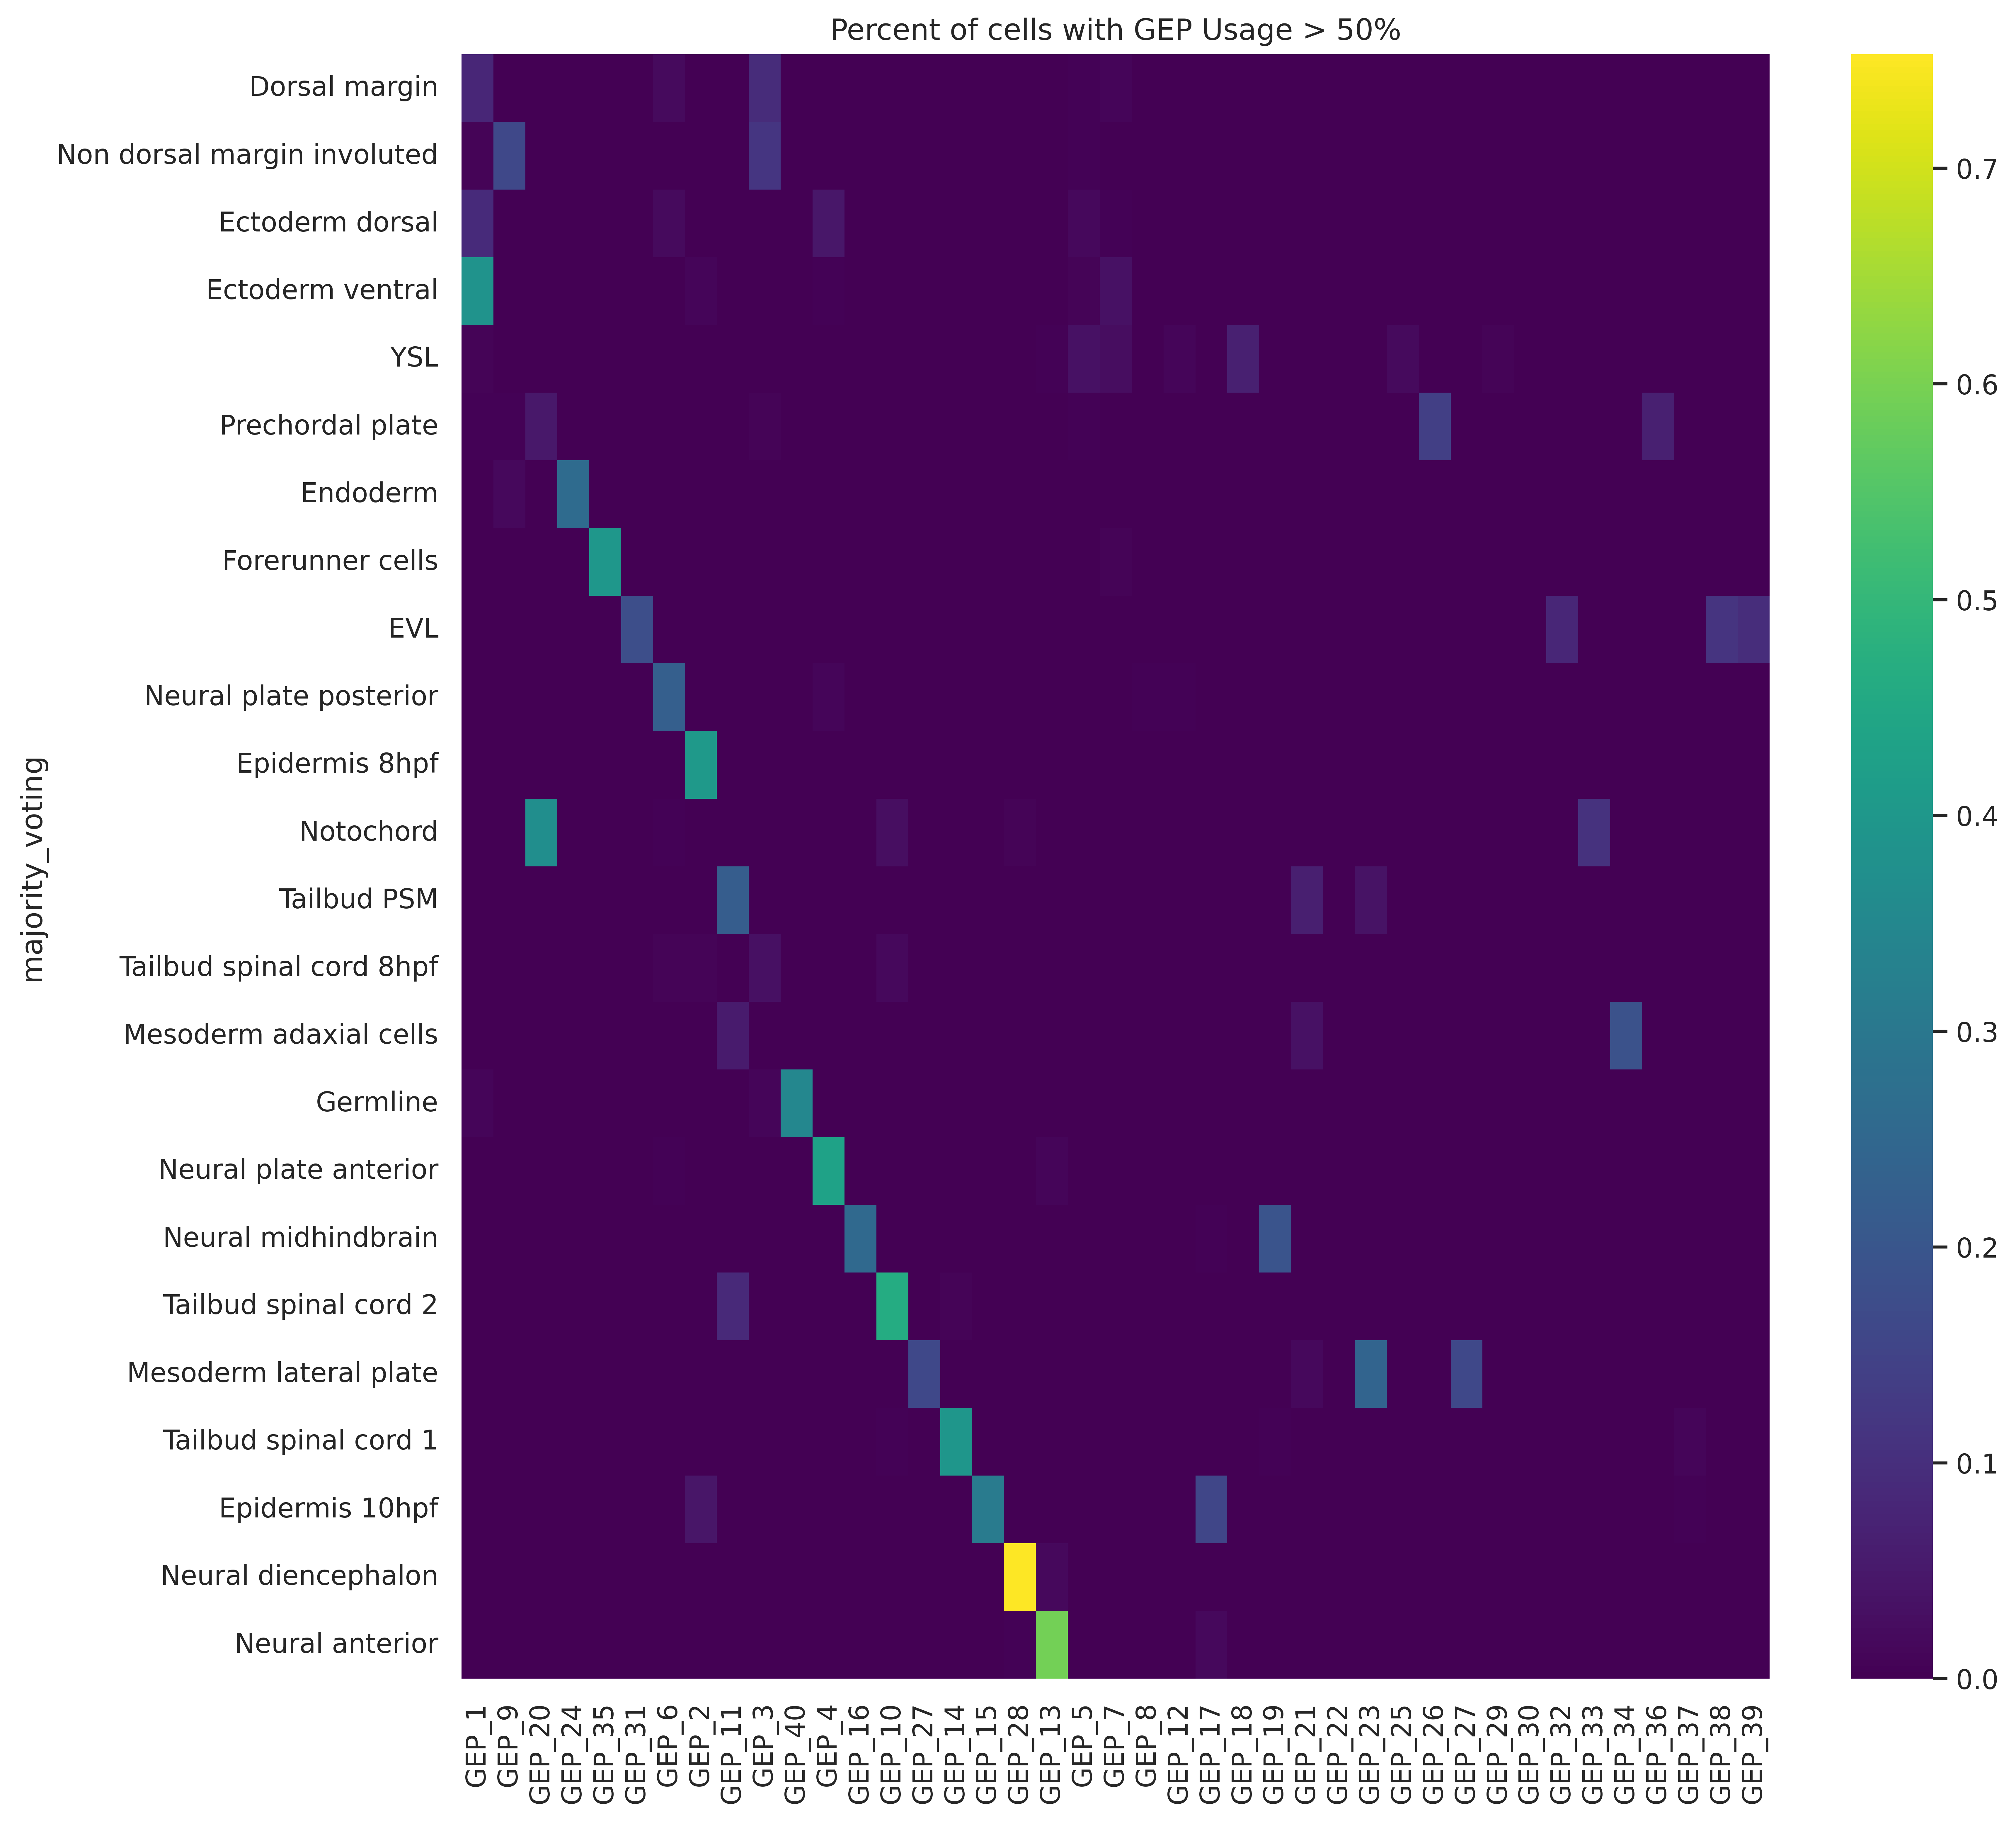

In [17]:
# Identify GEPs that represent cluster identities
usage_matrix_norm = usage_matrix.div(usage_matrix.sum(axis=1), axis=0)

percent_group_usage = usage_matrix_norm.groupby(adata.obs['majority_voting'], axis=0).apply(lambda x: (x>.5).mean())
roworder = clusters


percent_group_usage = percent_group_usage.loc[roworder, :]
gep_reordering = row_order_manual

sns.set(font_scale = 1)
(fig,ax) = plt.subplots(1,1,figsize=(12,12), dpi=600)
sns.heatmap(percent_group_usage.loc[:,gep_reordering], ax=ax, cmap='viridis')
ax.set_title('Percent of cells with GEP Usage > 50%')
plt.savefig('/your/path/gep_cluster_usage_heatmap_ordered_manual.tif', bbox_inches='tight')
plt.savefig('/your/path/gep_cluster_usage_heatmap_ordered_manual.svg', bbox_inches='tight')

/tmp/ipykernel_4717/195312742.py:4: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  percent_group_usage = usage_matrix_norm.groupby(adata.obs['majority_voting'], axis=0).apply(lambda x: (x>.25).mean())
/tmp/ipykernel_4717/195312742.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percent_group_usage = usage_matrix_norm.groupby(adata.obs['majority_voting'], axis=0).apply(lambda x: (x>.25).mean())


Text(0.5, 97.04687499999997, 'Inferred GEP')

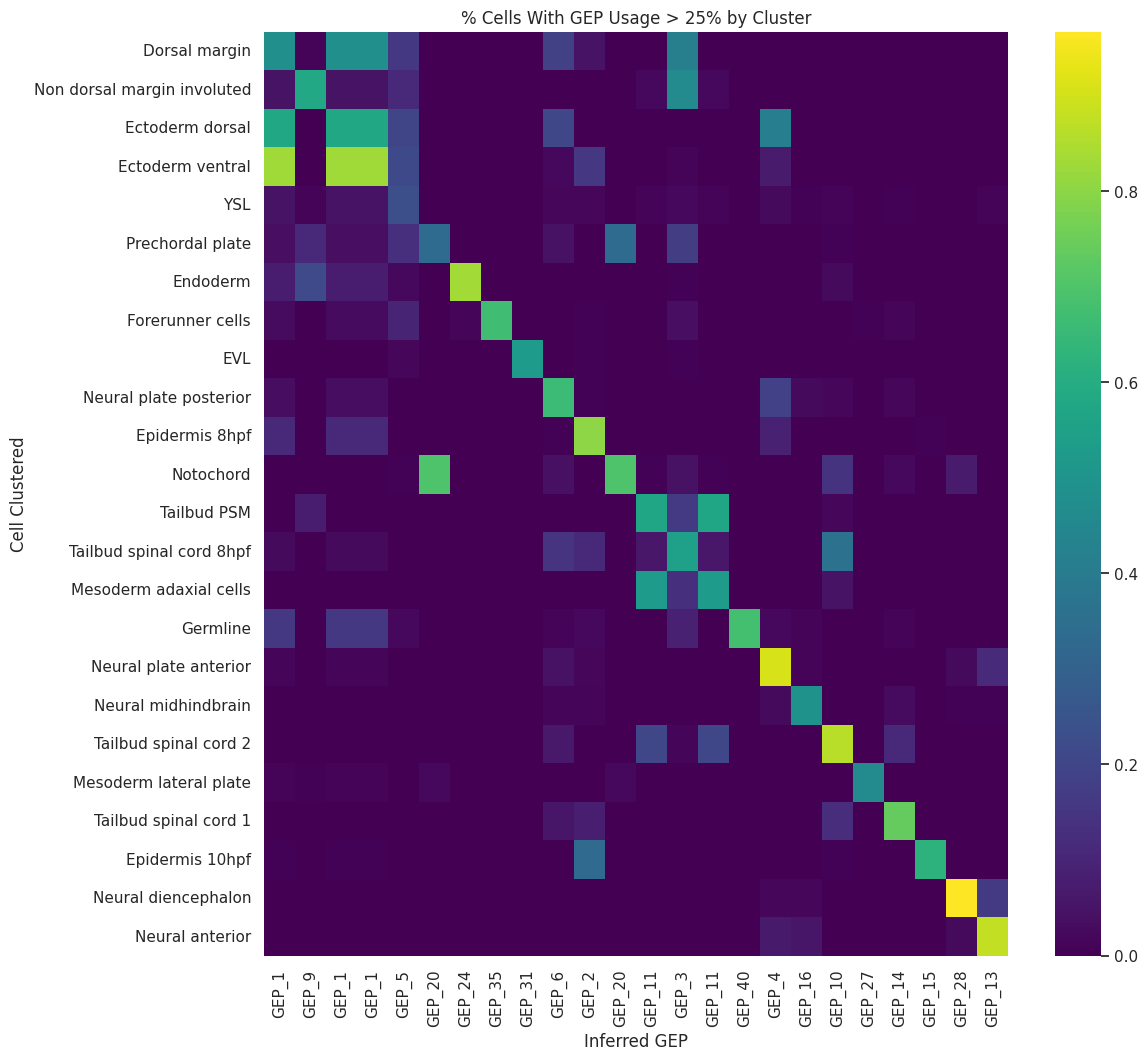

In [18]:
# Identify GEPs that represent cluster identities
usage_matrix_norm = usage_matrix.div(usage_matrix.sum(axis=1), axis=0)

percent_group_usage = usage_matrix_norm.groupby(adata.obs['majority_voting'], axis=0).apply(lambda x: (x>.25).mean())
roworder = clusters


percent_group_usage = percent_group_usage.loc[roworder, :]
gep_reordering = row_order

sns.set(font_scale = 1)
(fig,ax) = plt.subplots(1,1,figsize=(12,12), dpi=100)
sns.heatmap(percent_group_usage.loc[:,gep_reordering], ax=ax, cmap='viridis')
ax.set_title('% Cells With GEP Usage > 25% by Cluster')
ax.set_ylabel('Cell Clustered')
ax.set_xlabel('Inferred GEP')

## Activity programs

'Activity programs' ideally represent core expression programs that correlate with biological activities that can be layered on top of cell identity programs

### By group

In [19]:
Groups = adata.obs['Group'].unique().tolist()


/tmp/ipykernel_4717/1642220709.py:4: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  percent_group_usage = usage_matrix_norm.groupby(adata.obs['Group'], axis=0).apply(lambda x: (x>.25).mean())
/tmp/ipykernel_4717/1642220709.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percent_group_usage = usage_matrix_norm.groupby(adata.obs['Group'], axis=0).apply(lambda x: (x>.25).mean())


Text(0.5, 97.04687499999997, 'Inferred GEP')

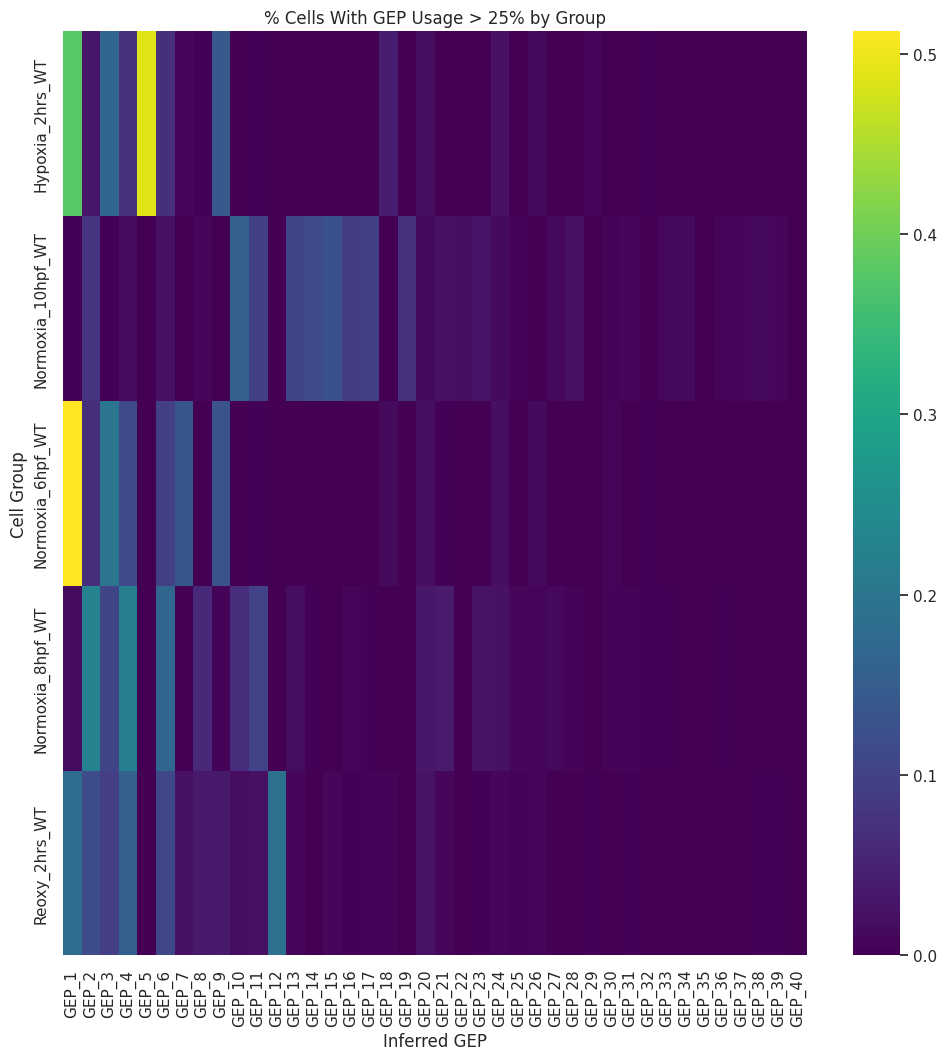

In [20]:
# Identify GEPs that represent Group identities
usage_matrix_norm = usage_matrix.div(usage_matrix.sum(axis=1), axis=0)

percent_group_usage = usage_matrix_norm.groupby(adata.obs['Group'], axis=0).apply(lambda x: (x>.25).mean())
roworder = Groups


percent_group_usage = percent_group_usage.loc[roworder, :]
gep_reordering = all_GEPs

sns.set(font_scale = 1)
(fig,ax) = plt.subplots(1,1,figsize=(12,12), dpi=100)
sns.heatmap(percent_group_usage.loc[:,gep_reordering], ax=ax, cmap='viridis')
ax.set_title('% Cells With GEP Usage > 25% by Group')
ax.set_ylabel('Cell Group')
ax.set_xlabel('Inferred GEP')

In [21]:
transposed = percent_group_usage.T
mono_identity_geps_dict = dict(transposed.idxmax())
mono_identity_geps_df = pd.DataFrame(transposed.idxmax())
mono_identity_geps_dict

{'Hypoxia_2hrs_WT': 'GEP_5',
 'Normoxia_10hpf_WT': 'GEP_10',
 'Normoxia_6hpf_WT': 'GEP_1',
 'Normoxia_8hpf_WT': 'GEP_2',
 'Reoxy_2hrs_WT': 'GEP_12'}

/tmp/ipykernel_4717/3334176629.py:4: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  percent_group_usage = usage_matrix_norm.groupby(adata.obs['Group'], axis=0).apply(lambda x: (x>.10).mean())
/tmp/ipykernel_4717/3334176629.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percent_group_usage = usage_matrix_norm.groupby(adata.obs['Group'], axis=0).apply(lambda x: (x>.10).mean())


Text(0.5, 97.04687499999997, 'Inferred GEP')

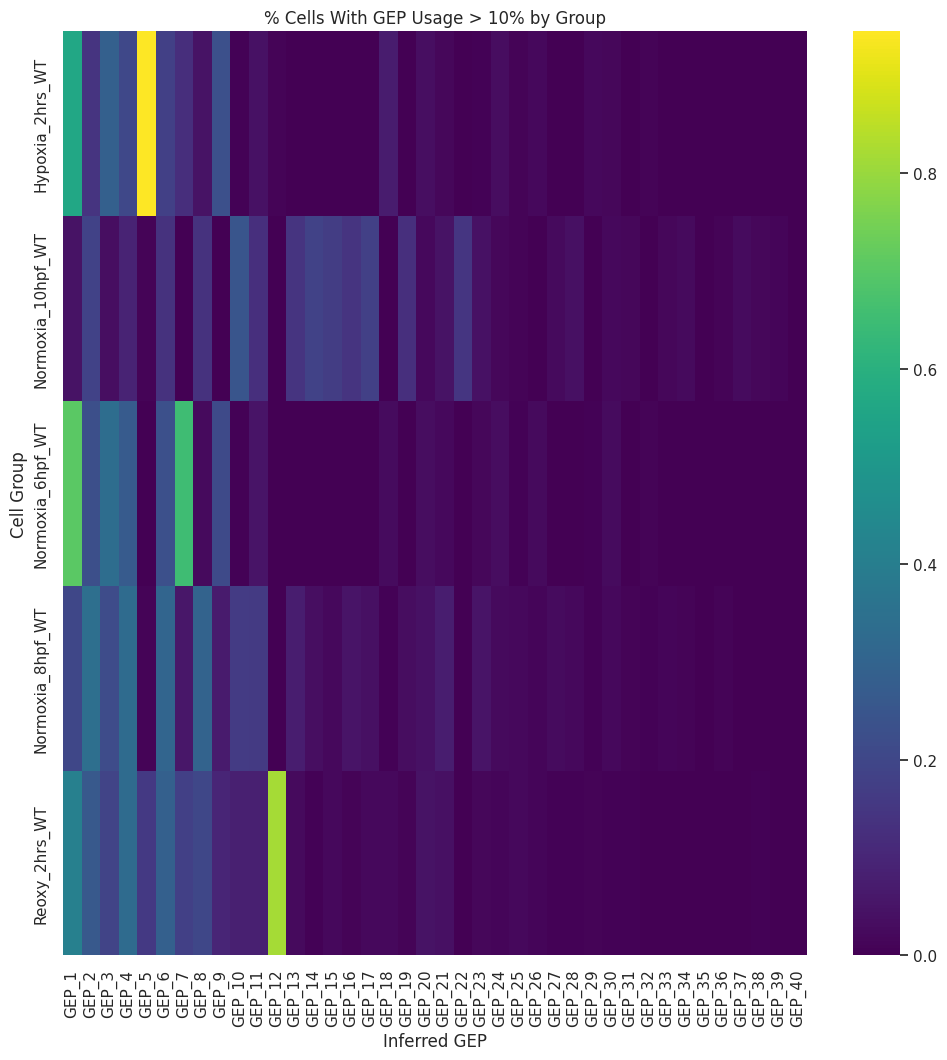

In [22]:
# Identify GEPs that represent Group identities
usage_matrix_norm = usage_matrix.div(usage_matrix.sum(axis=1), axis=0)

percent_group_usage = usage_matrix_norm.groupby(adata.obs['Group'], axis=0).apply(lambda x: (x>.10).mean())
roworder = Groups


percent_group_usage = percent_group_usage.loc[roworder, :]
gep_reordering = all_GEPs

sns.set(font_scale = 1)
(fig,ax) = plt.subplots(1,1,figsize=(12,12), dpi=100)
sns.heatmap(percent_group_usage.loc[:,gep_reordering], ax=ax, cmap='viridis')
ax.set_title('% Cells With GEP Usage > 10% by Group')
ax.set_ylabel('Cell Group')
ax.set_xlabel('Inferred GEP')

In [23]:
transposed = percent_group_usage.T
mono_identity_geps_dict = dict(transposed.idxmax())
mono_identity_geps_df = pd.DataFrame(transposed.idxmax())
mono_identity_geps_dict

{'Hypoxia_2hrs_WT': 'GEP_5',
 'Normoxia_10hpf_WT': 'GEP_10',
 'Normoxia_6hpf_WT': 'GEP_1',
 'Normoxia_8hpf_WT': 'GEP_2',
 'Reoxy_2hrs_WT': 'GEP_12'}

### By condition

In [27]:
Condition = adata.obs['Condition'].unique().tolist()


/tmp/ipykernel_4717/2024596707.py:4: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  percent_group_usage = usage_matrix_norm.groupby(adata.obs['Condition'], axis=0).apply(lambda x: (x>.10).mean())
/tmp/ipykernel_4717/2024596707.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percent_group_usage = usage_matrix_norm.groupby(adata.obs['Condition'], axis=0).apply(lambda x: (x>.10).mean())


Text(0.5, 97.04687499999997, 'Inferred GEP')

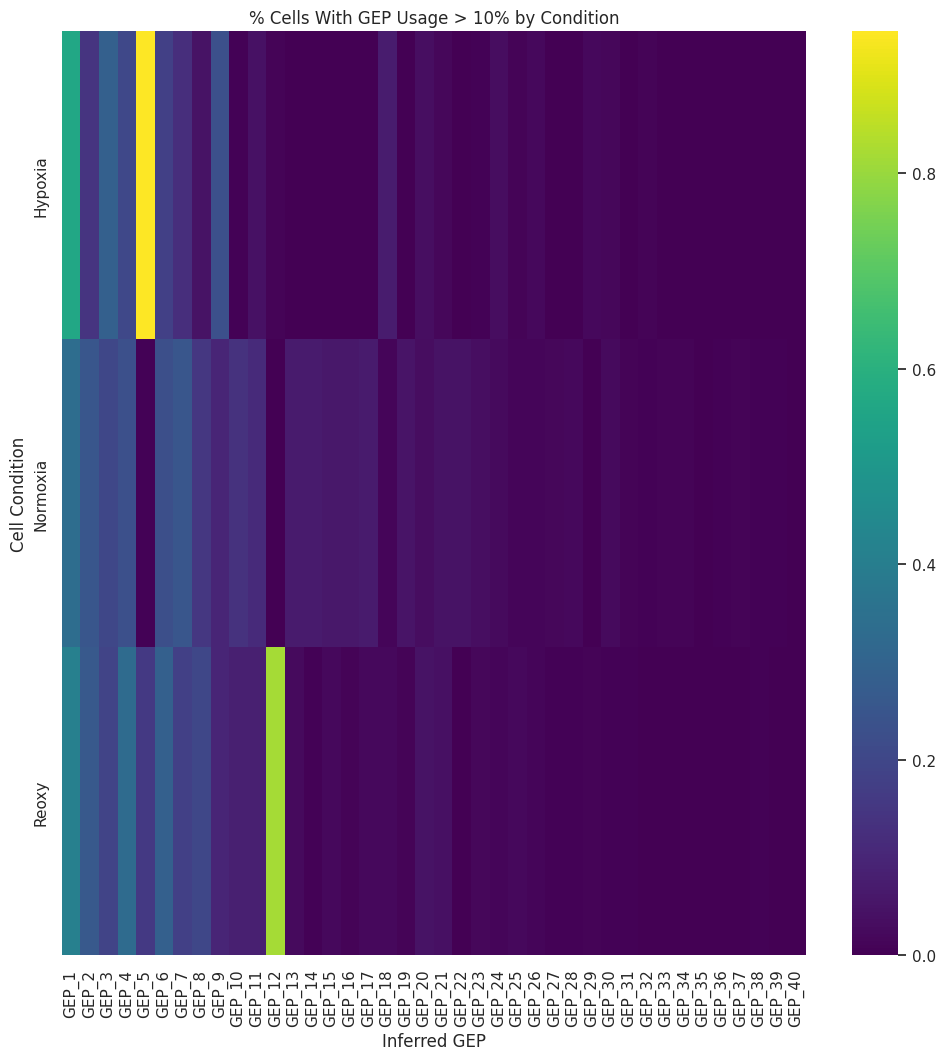

In [28]:
# Identify GEPs that represent Condition identities
usage_matrix_norm = usage_matrix.div(usage_matrix.sum(axis=1), axis=0)

percent_group_usage = usage_matrix_norm.groupby(adata.obs['Condition'], axis=0).apply(lambda x: (x>.10).mean())
roworder = Condition


percent_group_usage = percent_group_usage.loc[roworder, :]
gep_reordering = all_GEPs

sns.set(font_scale = 1)
(fig,ax) = plt.subplots(1,1,figsize=(12,12), dpi=100)
sns.heatmap(percent_group_usage.loc[:,gep_reordering], ax=ax, cmap='viridis')
ax.set_title('% Cells With GEP Usage > 10% by Condition')
ax.set_ylabel('Cell Condition')
ax.set_xlabel('Inferred GEP')

In [29]:
transposed = percent_group_usage.T
mono_identity_geps_dict = dict(transposed.idxmax())
mono_identity_geps_df = pd.DataFrame(transposed.idxmax())
mono_identity_geps_dict

{'Hypoxia': 'GEP_5', 'Normoxia': 'GEP_1', 'Reoxy': 'GEP_12'}

/tmp/ipykernel_4717/2040586789.py:4: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  percent_group_usage = usage_matrix_norm.groupby(adata.obs['Condition'], axis=0).apply(lambda x: (x>.05).mean())
/tmp/ipykernel_4717/2040586789.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percent_group_usage = usage_matrix_norm.groupby(adata.obs['Condition'], axis=0).apply(lambda x: (x>.05).mean())


Text(0.5, 1.0, 'Percent of cells with GEP Usage > 5% by Condition')

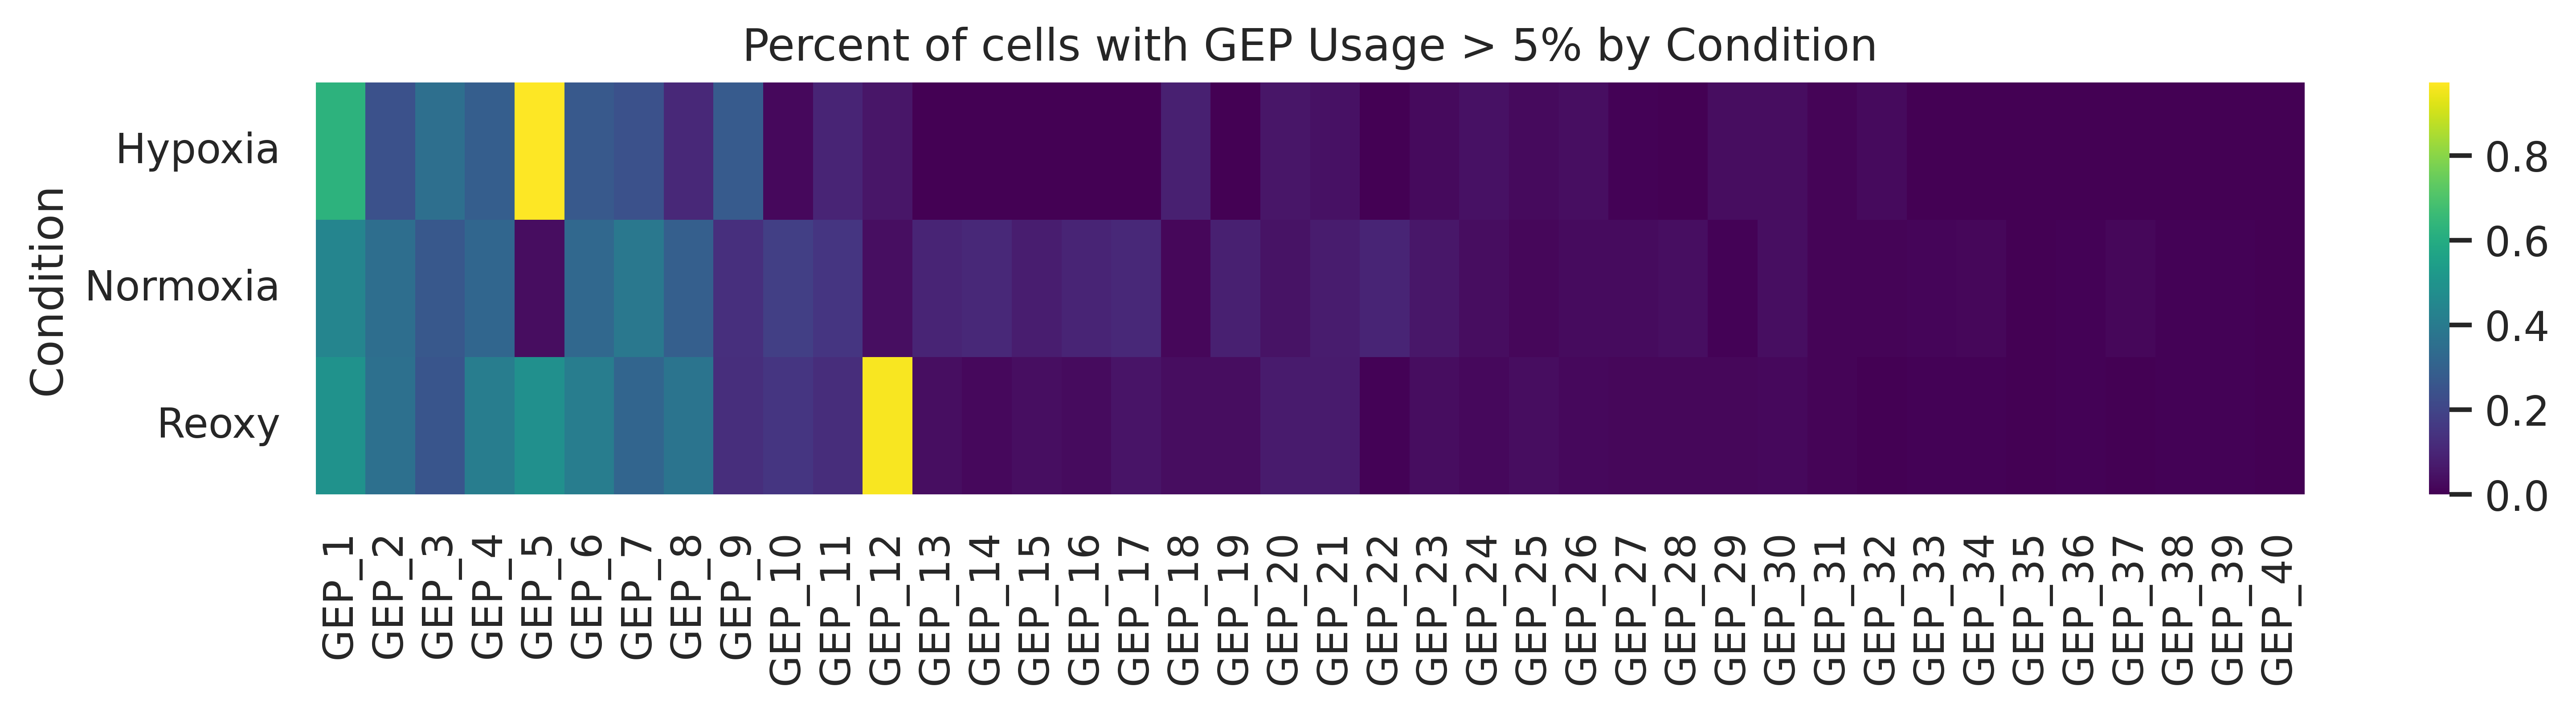

In [30]:
# Identify GEPs that represent Condition identities
usage_matrix_norm = usage_matrix.div(usage_matrix.sum(axis=1), axis=0)

percent_group_usage = usage_matrix_norm.groupby(adata.obs['Condition'], axis=0).apply(lambda x: (x>.05).mean())
roworder = Condition


percent_group_usage = percent_group_usage.loc[roworder, :]
gep_reordering = all_GEPs

sns.set(font_scale = 1)
(fig,ax) = plt.subplots(1,1,figsize=(12,2), dpi=600)
sns.heatmap(percent_group_usage.loc[:,gep_reordering], ax=ax, cmap='viridis')
ax.set_title('Percent of cells with GEP Usage > 5% by Condition')
plt.savefig('/your/path/gep_cluster_usage_heatmap_condition2.tif', bbox_inches='tight')
plt.savefig('/your/path/gep_cluster_usage_heatmap_condition2.svg', bbox_inches='tight')

## Gene expression program usage across cell types

In [34]:
# keep clusters that have sufficient replicates

enough = ['Normoxia_6hpf_WT', 'Hypoxia_2hrs_WT']
adata_shield = adata[adata.obs['Group'].isin(enough)].copy()
enough = ['Mesoderm lateral plate']
adata_shield = adata_shield[~adata_shield.obs['majority_voting'].isin(enough)].copy()

/tmp/ipykernel_4717/2686547451.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  justobs.groupby('majority_voting')[GEP]
/tmp/ipykernel_4717/2686547451.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=1, weight='bold')


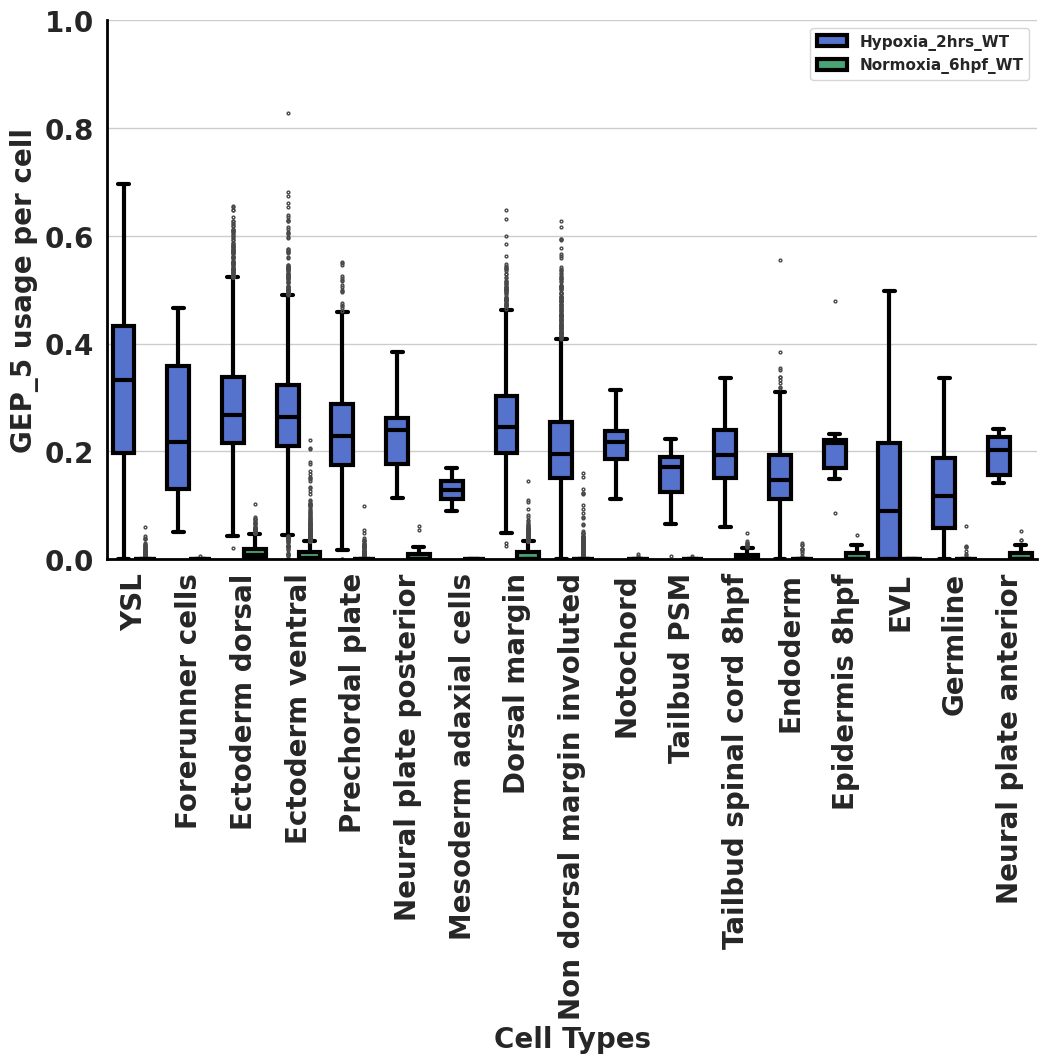

In [39]:
justobs = pd.DataFrame(adata_shield.obs)

GEP = 'GEP_5'

# Compute mean GEP_5 usage per majority_voting group
order = (
    justobs.groupby('majority_voting')[GEP]
    .mean()
    .sort_values(ascending=False)
    .index
)
custom_palette = {
    'Hypoxia_2hrs_WT': 'royalblue',  # Color for "Hypoxia"
    'Normoxia_6hpf_WT': 'mediumseagreen',  # Color for "Normoxia"
}


plt.rcParams['figure.figsize'] = 12, 7

ax = sns.boxplot(
    data=justobs,
    x="majority_voting",
    y=GEP,
    hue='Group',
    fliersize=2,
    order=order,
    palette=custom_palette,
    linewidth=3,
    boxprops=dict(edgecolor='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black')
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=1, weight='bold')

sns.set_style("whitegrid")
sns.despine()
ax.set_xlabel("Cell Types", fontsize=20, weight='bold')
ax.set_ylabel(str(GEP) + ' usage per cell', fontsize=20, weight='bold')
ax.spines['left'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.tick_params(labelsize=20)

# Make legend text bold
legend = ax.legend(fontsize=20, prop={'weight': 'bold'})

# Make tick labels bold
for label in ax.get_yticklabels():
    label.set_weight('bold')


ax.set(ylim=(0, 1))

plt.savefig('/your/path/GEP_5_usage_bycelltypeBold.tif', bbox_inches='tight', dpi = 300)  # or .pdf, .svg, etc.

plt.show()

/tmp/ipykernel_4717/768479976.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  justobs.groupby('majority_voting')[GEP]
/tmp/ipykernel_4717/768479976.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=1, weight='bold')


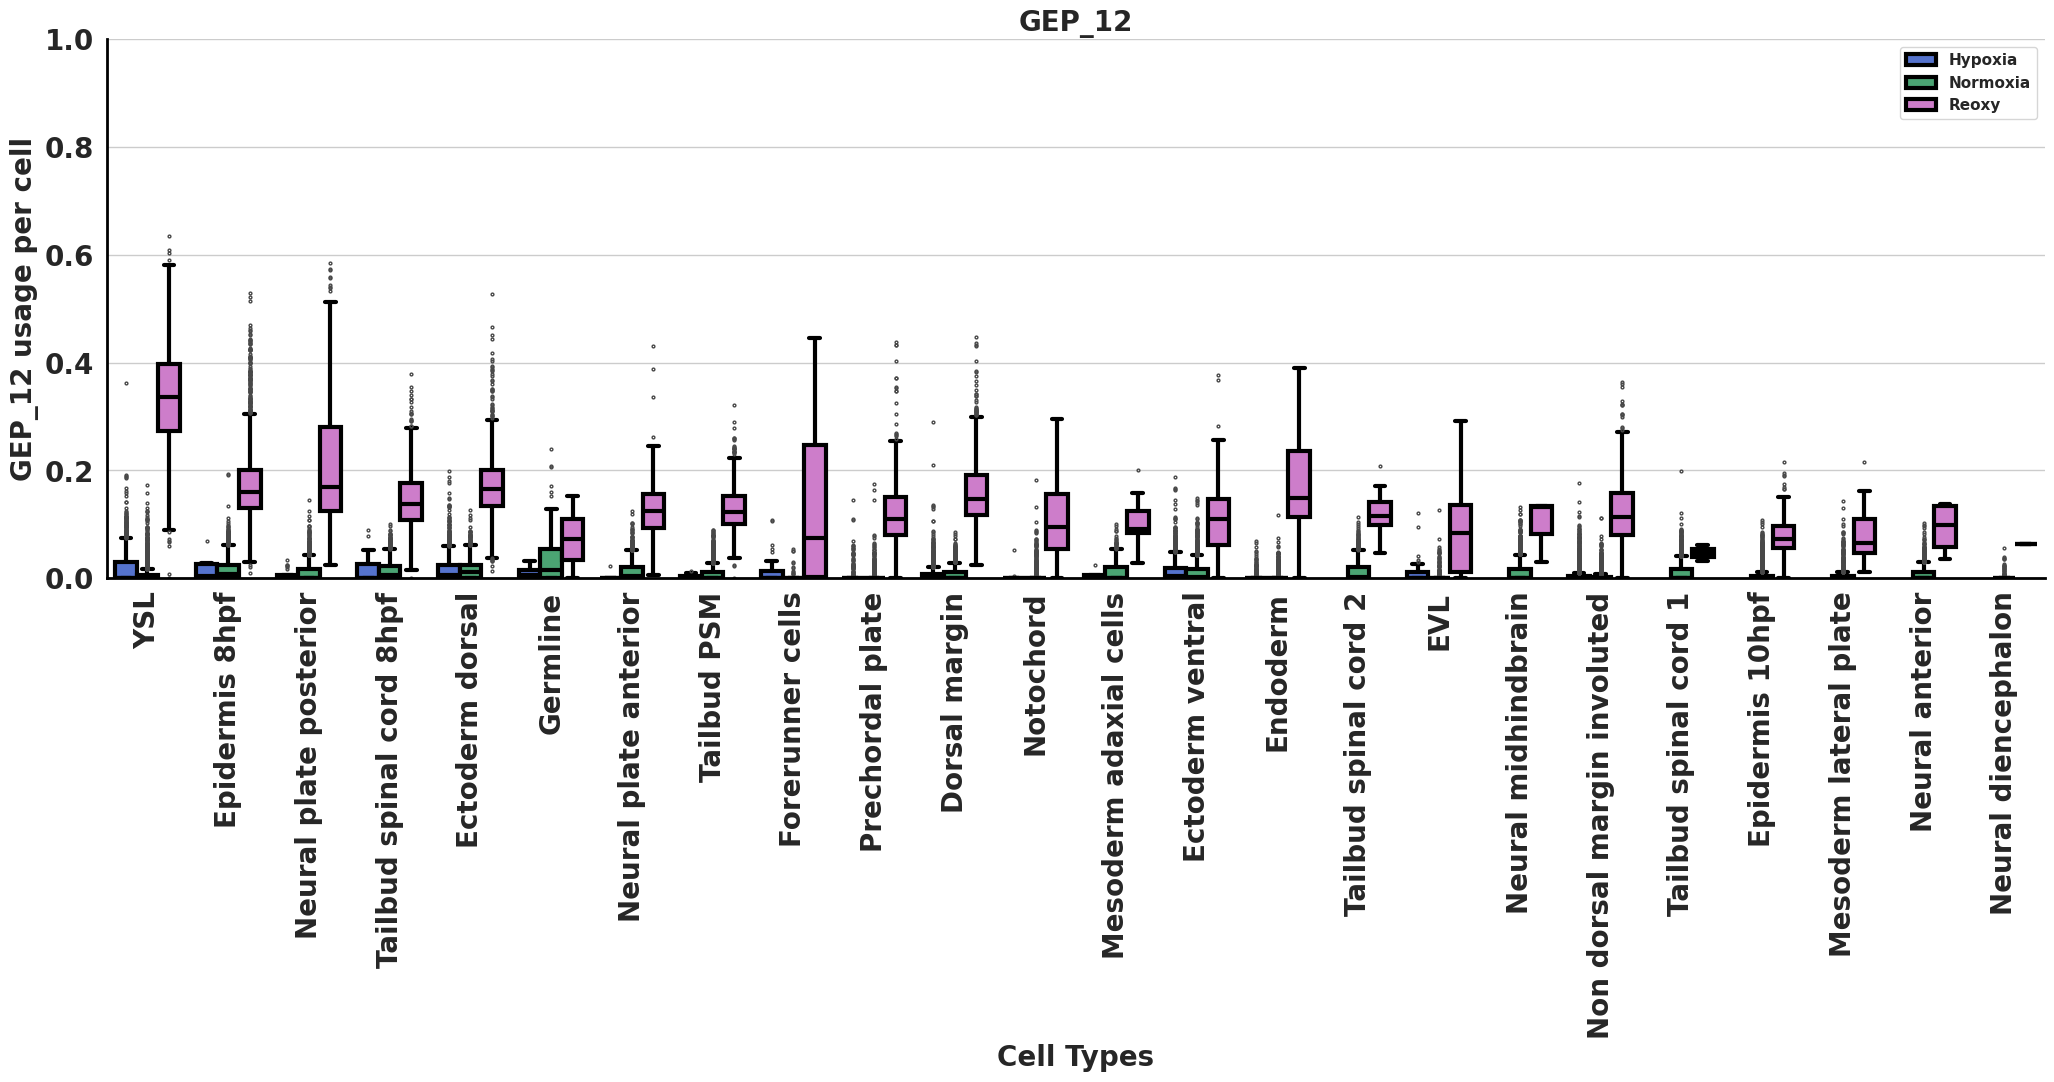

In [42]:
justobs = pd.DataFrame(adata.obs)

GEP = 'GEP_12'

plt.rcParams['figure.figsize'] = 25, 7

custom_palette = {
    'Hypoxia': 'royalblue',  # Color for "Hypoxia"
    'Normoxia': 'mediumseagreen',  # Color for "Normoxia"
    'Reoxy': 'orchid',  # Color for "Reoxy"
}

# Compute mean GEP_12 usage per majority_voting group
order = (
    justobs.groupby('majority_voting')[GEP]
    .mean()
    .sort_values(ascending=False)
    .index
)

ax = sns.boxplot(
    data=justobs,
    x="majority_voting",
    y=GEP,
    hue='Condition',
    fliersize=2,
    palette=custom_palette,
    linewidth=3,
    order=order,
    boxprops=dict(edgecolor='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black')
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=1, weight='bold')

ax.axes.set_title(GEP, fontsize=20, weight='bold')
sns.set_style("whitegrid")
sns.despine()
ax.spines['left'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.set_xlabel("Cell Types", fontsize=20, weight='bold')
ax.set_ylabel(str(GEP) + ' usage per cell', fontsize=20, weight='bold')
ax.tick_params(labelsize=20)

# Make legend text bold
legend = ax.legend(fontsize=20, prop={'weight': 'bold'})

# Make tick labels bold
for label in ax.get_yticklabels():
    label.set_weight('bold')

ax.set(ylim=(0, 1))

plt.savefig('/your/path/GEP_12_usage_bycelltypeBold.tif', bbox_inches='tight', dpi = 300)  # or .pdf, .svg, etc.


plt.show()